# Experiment 20260801_154936: end-to-end accuracy

This notebook summarizes the tested generation configurations and plots the **end-to-end accuracy of every answer-extraction method for every individual run** on a fixed **0–100%** scale. The source is `experiment_report.md` plus each run's `extractor_accuracy.json`; each run used 500 examples, and every model/configuration pair was repeated three times.

The matrix contains four models and 17 configurations per model: 16 combinations for `iterative` and `cot`, plus one `direct_query` baseline. This gives 4 × 17 × 3 = **204 runs**.

## What the configurations mean

| Dimension | Values tested | Brief explanation |
|---|---|---|
| Model | Qwen2.5-7B, Qwen2.5-32B, Llama-4-Scout-17B-16E, Mistral-7B-v0.2 | The instruction-tuned model used for generation. |
| Strategy | `iterative`, `cot`, `direct_query` | `iterative` generates one table action per step; `cot` uses two-phase Chain-of-Table action selection and argument generation; `direct_query` skips table transformations and answers directly. |
| Constraints | `off`, `on` | Whether constrained decoding enforces valid action syntax and arguments. |
| Global | `off`, `on` | Whether LEAP's action-transition matrix restricts which action may follow the latest action. |
| Backend | `xgrammar` | The constrained-decoding implementation. Backend is meaningful only when constraints are enabled; compact display labels omit it for unconstrained runs. |
| Format | `function`, `json` | Actions are represented either as function-like calls or named JSON objects. |
| vLLM | `modern` | All runs used the modern vLLM runtime. |

For `iterative` and `cot`, all 2 × 2 × 2 combinations of constraints, global constraints, and format were tested. `direct_query` was intentionally collapsed to one unconstrained function-format configuration because action constraints do not apply to it.

### Answer extraction methods

Each generated final table was evaluated with five independent answer extractors: `direct_query` asks the model for the answer directly; `nl2sql` generates and executes SQL; `nl2code` generates and executes dataframe code; `end2ender` uses a direct end-to-end table-QA prompt; and `cot_end2ender` uses its chain-of-thought variant. **Mean** is the arithmetic mean of those five accuracies. The report's single `Accuracy` column is this mean, not a sixth extraction method.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython import get_ipython
from IPython.display import Markdown, display
from matplotlib.patches import Patch

get_ipython().run_line_magic("matplotlib", "inline")

REPORT = Path("/home/hosak/LEAP/results/experiments/20260801_154936/experiment_report.md")
assert REPORT.exists(), f"Report not found: {REPORT}"
report_text = REPORT.read_text(encoding="utf-8")
print(f"Loaded {REPORT}")

Loaded /home/hosak/LEAP/results/experiments/20260801_154936/experiment_report.md


In [2]:
def markdown_table(section_title):
    section = report_text.split(f"## {section_title}", 1)[1]
    lines = section.splitlines()
    table_lines = []
    started = False
    for line in lines:
        if line.startswith("|"):
            started = True
            table_lines.append(line)
        elif started:
            break
    header = [cell.strip() for cell in table_lines[0].strip("|").split("|")]
    rows = []
    for line in table_lines[2:]:  # skip header and Markdown separator
        values = [cell.strip() for cell in line.strip("|").split("|")]
        rows.append(dict(zip(header, values)))
    return rows


runs = markdown_table("Individual Runs")
for run in runs:
    run["Repeat"] = int(run["Repeat"])
    run["Examples"] = int(run["Examples"])

EXTRACTORS = ("direct_query", "nl2sql", "nl2code", "end2ender", "cot_end2ender")
METRICS = EXTRACTORS + ("mean",)
METRIC_LABELS = {
    "direct_query": "Direct query",
    "nl2sql": "NL-to-SQL",
    "nl2code": "NL-to-code",
    "end2ender": "End-to-ender",
    "cot_end2ender": "Chain-of-thought end-to-ender",
    "mean": "Mean across all five extractors",
}

for run in runs:
    accuracy_file = Path(run["Run Dir"]) / "extractor_accuracy.json"
    extractor_report = json.loads(accuracy_file.read_text(encoding="utf-8"))
    method_accuracies = extractor_report["method_accuracies"]
    assert tuple(method_accuracies) == EXTRACTORS, f"Unexpected extractors in {accuracy_file}"
    for method in EXTRACTORS:
        run[f"{method} %"] = 100 * float(method_accuracies[method])
    run["mean %"] = 100 * float(extractor_report["average_accuracy"])
    assert abs(run["mean %"] - 100 * float(run["Accuracy"])) < 0.051, f"Report Accuracy is not the extractor mean for {run['Run Dir']}"

models = list(dict.fromkeys(run["Model"] for run in runs))
print(f"Parsed {len(runs)} runs across {len(models)} models.")

Parsed 204 runs across 4 models.


In [3]:
# Completeness checks: fail loudly if the report changes or parsing omits a run.
config_fields = ("Strategy", "Constraints", "Global", "Backend", "Format")
config_count = Counter((r["Model"],) + tuple(r[f] for f in config_fields) for r in runs)

assert len(runs) == 204, f"Expected 204 runs, found {len(runs)}"
assert set(config_count.values()) == {3}, "Each model/configuration should have exactly three repeats."
assert all(r["Status"] == "ok" for r in runs), "At least one run did not finish successfully."
assert all(0 <= r[f"{metric} %"] <= 100 for r in runs for metric in METRICS), "Accuracy outside 0–100%."

for model in models:
    model_runs = [r for r in runs if r["Model"] == model]
    n_configs = len({tuple(r[f] for f in config_fields) for r in model_runs})
    print(f"{model}: {len(model_runs)} runs, {n_configs} configurations")

Qwen/Qwen2.5-7B-Instruct: 51 runs, 17 configurations
Qwen/Qwen2.5-32B-Instruct: 51 runs, 17 configurations
meta-llama/Llama-4-Scout-17B-16E-Instruct: 51 runs, 17 configurations
mistralai/Mistral-7B-Instruct-v0.2: 51 runs, 17 configurations


## Configuration key

The charts use compact IDs (`C01`–`C17`). The following generated table is the exact configuration catalog found in the report.

In [4]:
configurations = list(dict.fromkeys(tuple(r[f] for f in config_fields) for r in runs))
config_ids = {config: f"C{i:02d}" for i, config in enumerate(configurations, 1)}
config_by_id = {config_id: config for config, config_id in config_ids.items()}

dq_baseline_configs = [config for config in configurations if config[0] == "direct_query"]
assert len(dq_baseline_configs) == 1, f"Expected one direct-query baseline configuration, found {len(dq_baseline_configs)}"
DQ_BASELINE_CONFIG = dq_baseline_configs[0]
DQ_BASELINE_ID = config_ids[DQ_BASELINE_CONFIG]
CONFIGURATION_PLOT_LABELS = {
    config_ids[config]: ("DQ baseline" if config == DQ_BASELINE_CONFIG else config_ids[config]) for config in configurations
}

configuration_catalog = pd.DataFrame(
    [
        {
            "ID": config_ids[config],
            "Plot label": CONFIGURATION_PLOT_LABELS[config_ids[config]],
            **dict(zip(config_fields, config)),
        }
        for config in configurations
    ]
)
configuration_catalog

,ID,Plot label,Strategy,Constraints,Global,Backend,Format
0,C01,C01,iterative,off,off,xgrammar,function
1,C02,C02,iterative,off,off,xgrammar,json
2,C03,C03,iterative,off,on,xgrammar,function
3,C04,C04,iterative,off,on,xgrammar,json
4,C05,C05,iterative,on,off,xgrammar,function
5,C06,C06,iterative,on,off,xgrammar,json
6,C07,C07,iterative,on,on,xgrammar,function
7,C08,C08,iterative,on,on,xgrammar,json
8,C09,C09,cot,off,off,xgrammar,function
9,C10,C10,cot,off,off,xgrammar,json


## Publication plot setup

The sections below report each answer extractor separately, beginning with **Direct query**. Every bar is a **single mean across the three 500-example runs** for one model/configuration pair; extractor scores are never averaged together. Small black capped error bars show sample standard deviation across the three runs.

The generation configuration with `Strategy=direct_query` is labeled **DQ baseline**. It appears first in per-model and all-configuration plots and is included as a reference in every backend/format category plot, including categories whose format differs from the baseline's function format.

Colors encode models only and remain fixed throughout. The numeric three-run mean is printed above every bar. The highest mean configuration in each plot is emphasized with a bold score and bold configuration label; tied maxima are all emphasized. Configuration IDs and the DQ baseline resolve to the complete decoding setup in the catalog above.

In [5]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

MODEL_LABELS = {
    "Qwen/Qwen2.5-7B-Instruct": "Qwen2.5-7B",
    "Qwen/Qwen2.5-32B-Instruct": "Qwen2.5-32B",
    "meta-llama/Llama-4-Scout-17B-16E-Instruct": "Llama-4-Scout",
    "mistralai/Mistral-7B-Instruct-v0.2": "Mistral-7B-v0.2",
}
MODEL_COLORS = dict(zip(models, sns.color_palette("colorblind", n_colors=len(models)).as_hex()))


def run_config(run):
    return tuple(run[field] for field in config_fields)


for run in runs:
    run["Configuration"] = config_ids[run_config(run)]
    run["Plot label"] = CONFIGURATION_PLOT_LABELS[run["Configuration"]]
    run["Model label"] = MODEL_LABELS[run["Model"]]
    run["Category"] = f"{run['Backend']} · {run['Format']}"

runs_df = pd.DataFrame(runs)
summary_fields = [
    "Model",
    "Model label",
    "Configuration",
    "Plot label",
    "Category",
    "Strategy",
    "Constraints",
    "Global",
    "Backend",
    "Format",
]
metric_columns = {f"{extractor} %": extractor for extractor in EXTRACTORS}
long_runs_df = runs_df.melt(
    id_vars=summary_fields,
    value_vars=list(metric_columns),
    var_name="Metric column",
    value_name="Extractor accuracy",
)
long_runs_df["Extractor"] = long_runs_df["Metric column"].map(metric_columns)
summary_df = (
    long_runs_df.groupby(summary_fields + ["Extractor"], sort=False, observed=True)["Extractor accuracy"]
    .agg(accuracy_mean="mean", accuracy_std="std", repeats="count")
    .reset_index()
)
assert len(summary_df) == len(EXTRACTORS) * len(models) * len(configurations)
assert set(summary_df["repeats"]) == {3}
summary_df

,Model,Model label,Configuration,Plot label,Category,Strategy,Constraints,Global,Backend,Format,Extractor,accuracy_mean,accuracy_std,repeats
0,Qwen/Qwen2.5-7B-Instruct,Qwen2.5-7B,C01,C01,xgrammar · function,iterative,off,off,xgrammar,function,direct_query,48.600000,0.721110,3
1,Qwen/Qwen2.5-7B-Instruct,Qwen2.5-7B,C02,C02,xgrammar · json,iterative,off,off,xgrammar,json,direct_query,45.933333,0.115470,3
2,Qwen/Qwen2.5-7B-Instruct,Qwen2.5-7B,C03,C03,xgrammar · function,iterative,off,on,xgrammar,function,direct_query,46.533333,0.642910,3
3,Qwen/Qwen2.5-7B-Instruct,Qwen2.5-7B,C04,C04,xgrammar · json,iterative,off,on,xgrammar,json,direct_query,47.266667,0.305505,3
4,Qwen/Qwen2.5-7B-Instruct,Qwen2.5-7B,C05,C05,xgrammar · function,iterative,on,off,xgrammar,function,direct_query,38.333333,1.792577,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-v0.2,C13,C13,xgrammar · function,cot,on,off,xgrammar,function,cot_end2ender,10.933333,0.416333,3
336,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-v0.2,C14,C14,xgrammar · json,cot,on,off,xgrammar,json,cot_end2ender,10.200000,0.346410,3
337,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-v0.2,C15,C15,xgrammar · function,cot,on,on,xgrammar,function,cot_end2ender,8.666667,0.416333,3
338,mistralai/Mistral-7B-Instruct-v0.2,Mistral-7B-v0.2,C16,C16,xgrammar · json,cot,on,on,xgrammar,json,cot_end2ender,10.000000,0.200000,3


In [6]:
def style_accuracy_axis(ax, title, xlabel, extractor):
    ax.set_title(title, pad=16)
    ax.set_xlabel(xlabel, labelpad=12)
    ax.set_ylabel(f"{METRIC_LABELS[extractor]} accuracy (%)")
    ax.set_ylim(0, 100)
    ax.set_yticks(range(0, 101, 20))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#c7c7c7", linestyle=(0, (2, 3)), linewidth=0.8)
    ax.grid(axis="x", visible=False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#333333")
        spine.set_linewidth(0.9)


def add_model_legend(ax, ncol=4):
    handles = [Patch(facecolor=MODEL_COLORS[m], edgecolor="black", linewidth=0.8, label=MODEL_LABELS[m]) for m in models]
    ax.legend(handles=handles, title="Model", loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=ncol, frameon=False)


def tick_configuration_id(tick_text):
    first_line = tick_text.split("\n", 1)[0]
    return DQ_BASELINE_ID if first_line.startswith("DQ baseline") else first_line


def emphasize_ticks(ax, best_configurations):
    for tick in ax.get_xticklabels():
        if tick_configuration_id(tick.get_text()) in best_configurations:
            tick.set_fontweight("bold")


def annotate_bar(ax, bar, value, std, is_best, rotation=0):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + std + 1.0,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        rotation=rotation,
        fontsize=8 if rotation else 9,
        fontweight="bold" if is_best else "normal",
    )


def grouped_model_bars(ax, frame, positions, configuration_ids, bar_width=0.19):
    best_mean = frame["accuracy_mean"].max()
    best_configurations = set(frame.loc[frame["accuracy_mean"].sub(best_mean).abs() < 1e-12, "Configuration"])
    offsets = (pd.Series(range(len(models)), dtype=float) - (len(models) - 1) / 2) * bar_width

    for offset, model in zip(offsets, models):
        model_frame = frame[frame["Model"] == model].set_index("Configuration")
        means = [model_frame.loc[config_id, "accuracy_mean"] for config_id in configuration_ids]
        stds = [model_frame.loc[config_id, "accuracy_std"] for config_id in configuration_ids]
        bars = ax.bar(
            positions + offset,
            means,
            yerr=stds,
            width=bar_width,
            color=MODEL_COLORS[model],
            edgecolor="black",
            linewidth=0.7,
            ecolor="black",
            capsize=3,
            error_kw={"elinewidth": 0.9, "capthick": 0.9},
        )
        for bar, value, std in zip(bars, means, stds):
            annotate_bar(ax, bar, value, std, abs(value - best_mean) < 1e-12, rotation=90)
    return best_configurations

## Accuracy by answer extractor

For each extractor, the notebook presents four per-model figures, the backend/format category comparisons, and one comparison across every configuration. Extractors are kept separate throughout; only the three repeated runs are averaged.

**DQ baseline** is the unconstrained, function-format `direct_query` generation configuration. It is positioned first and repeated as a reference in each category comparison.

### Direct query

#### Per-model configurations

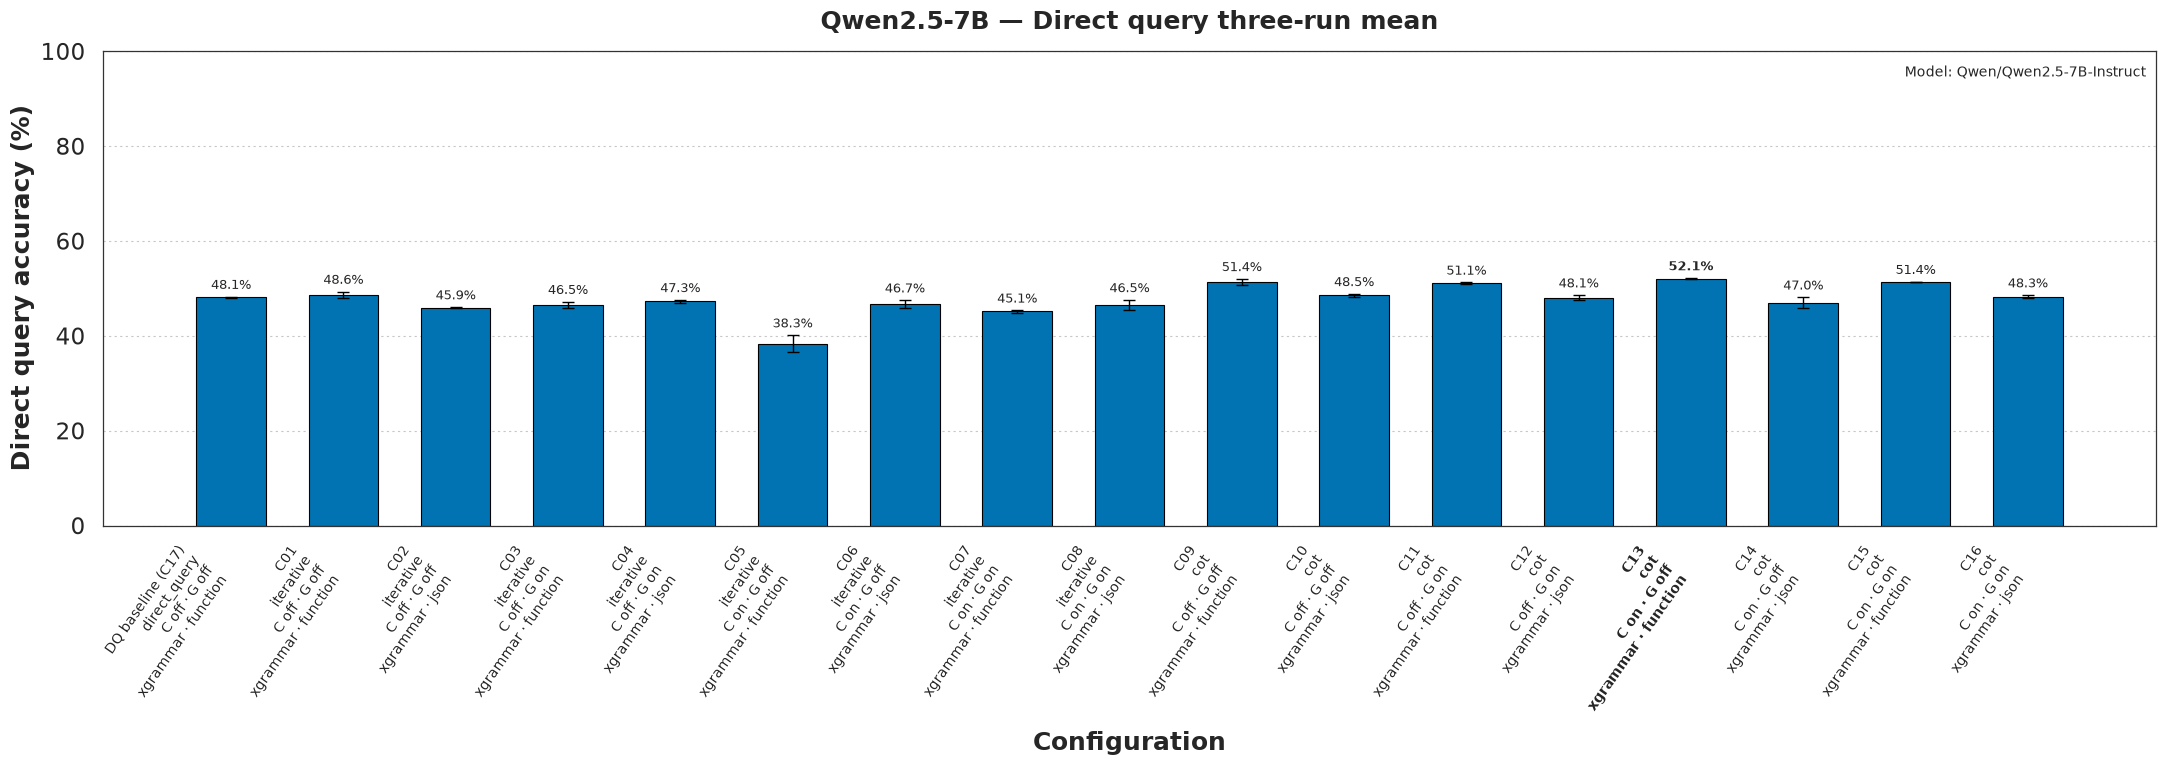

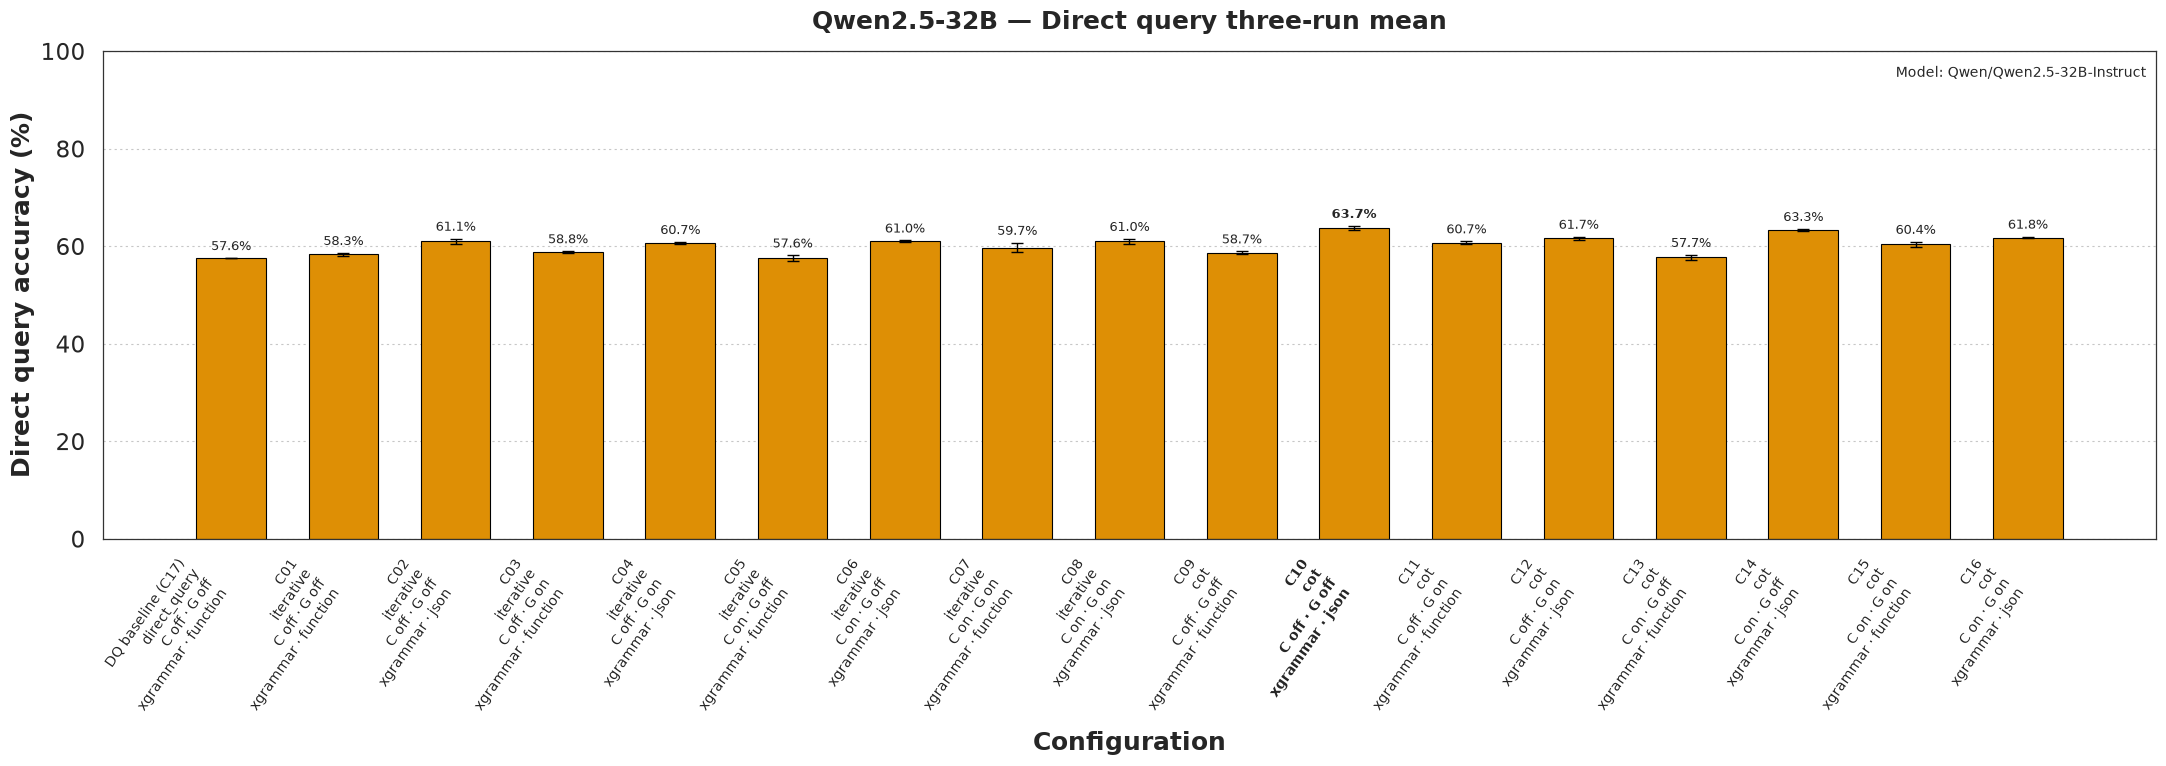

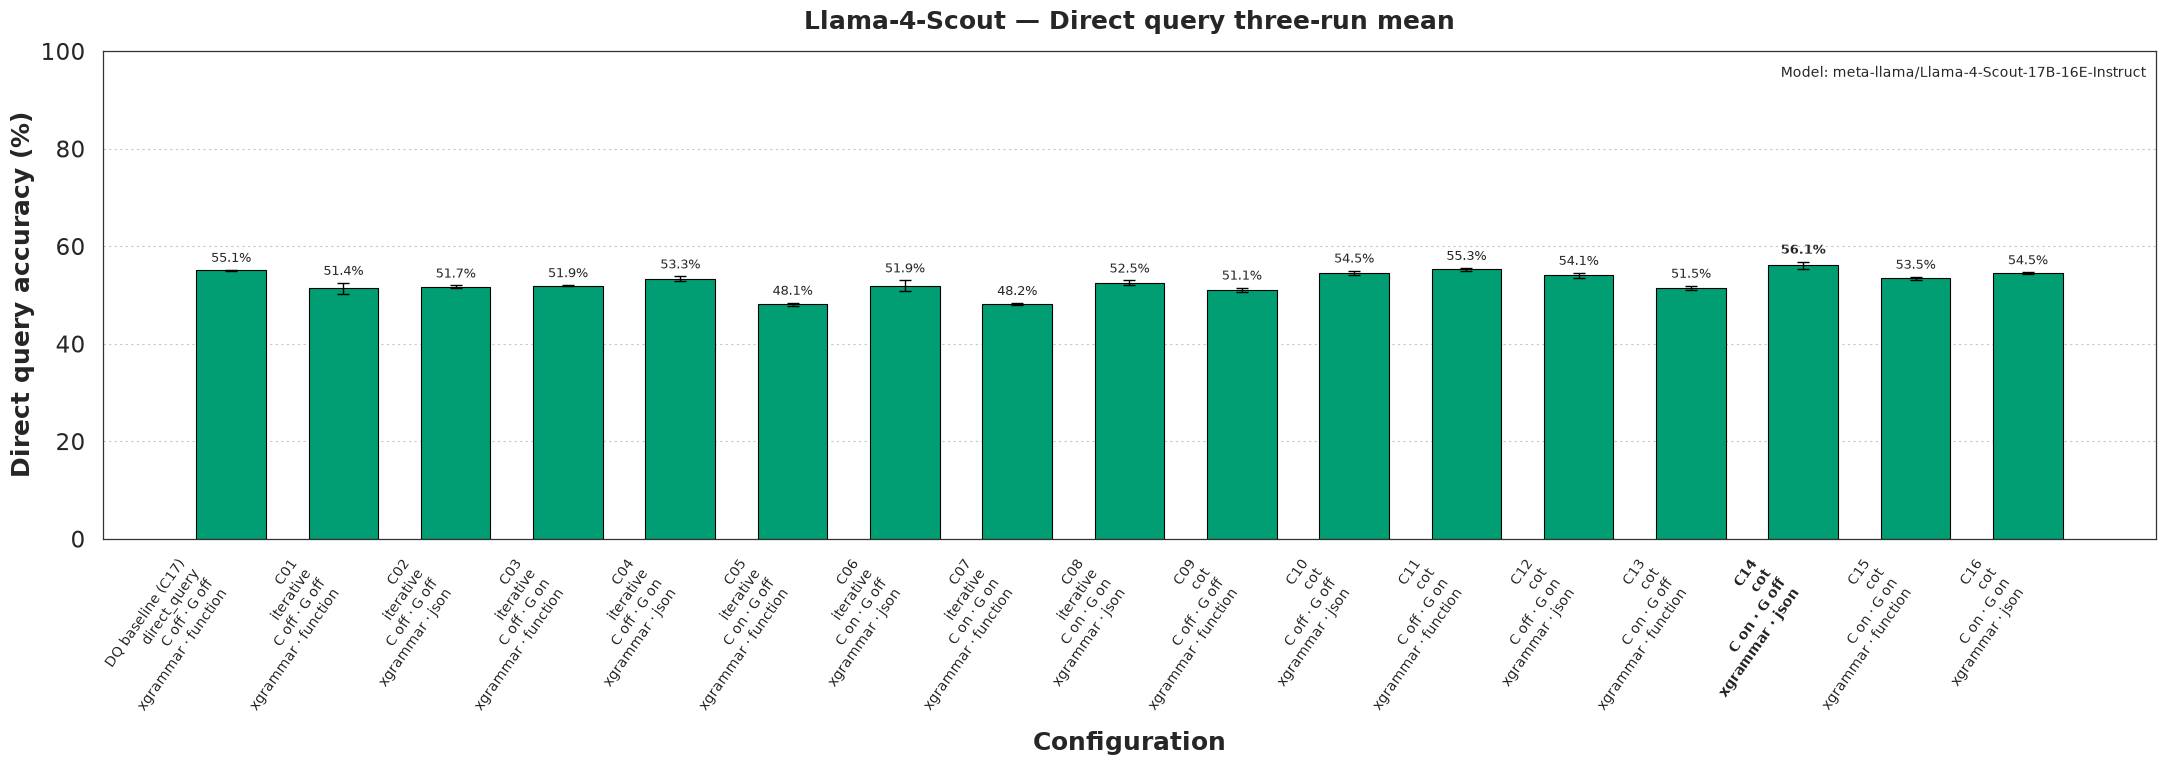

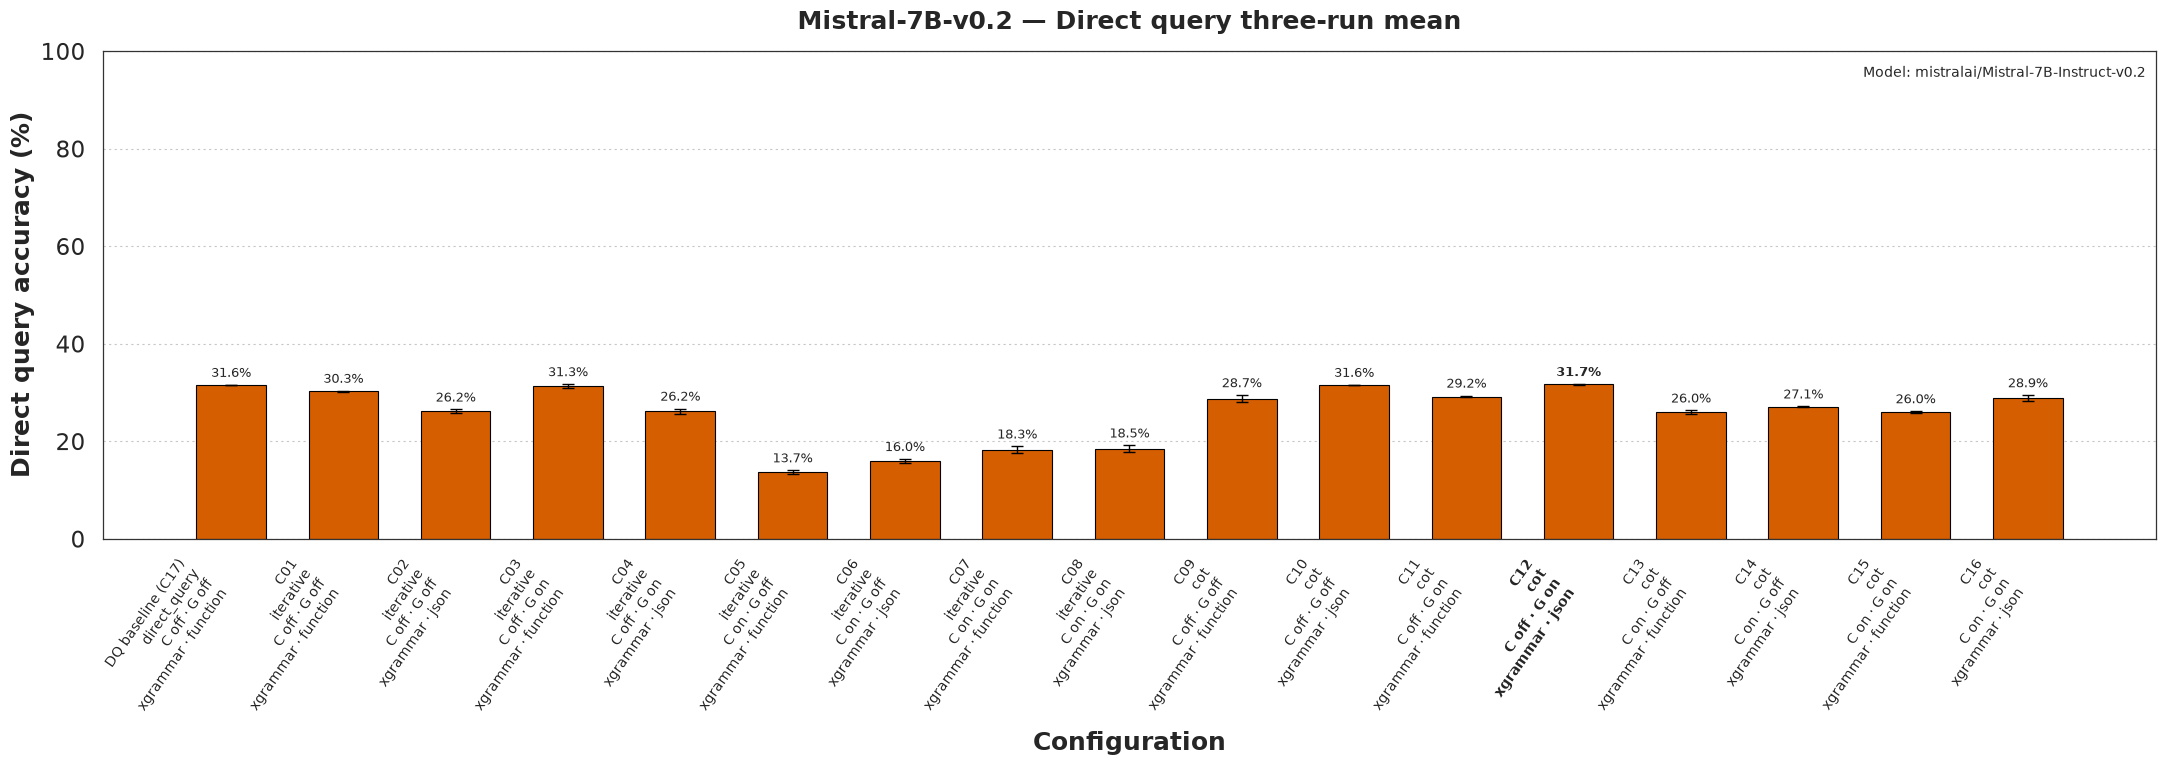

#### Per-experiment-category comparisons

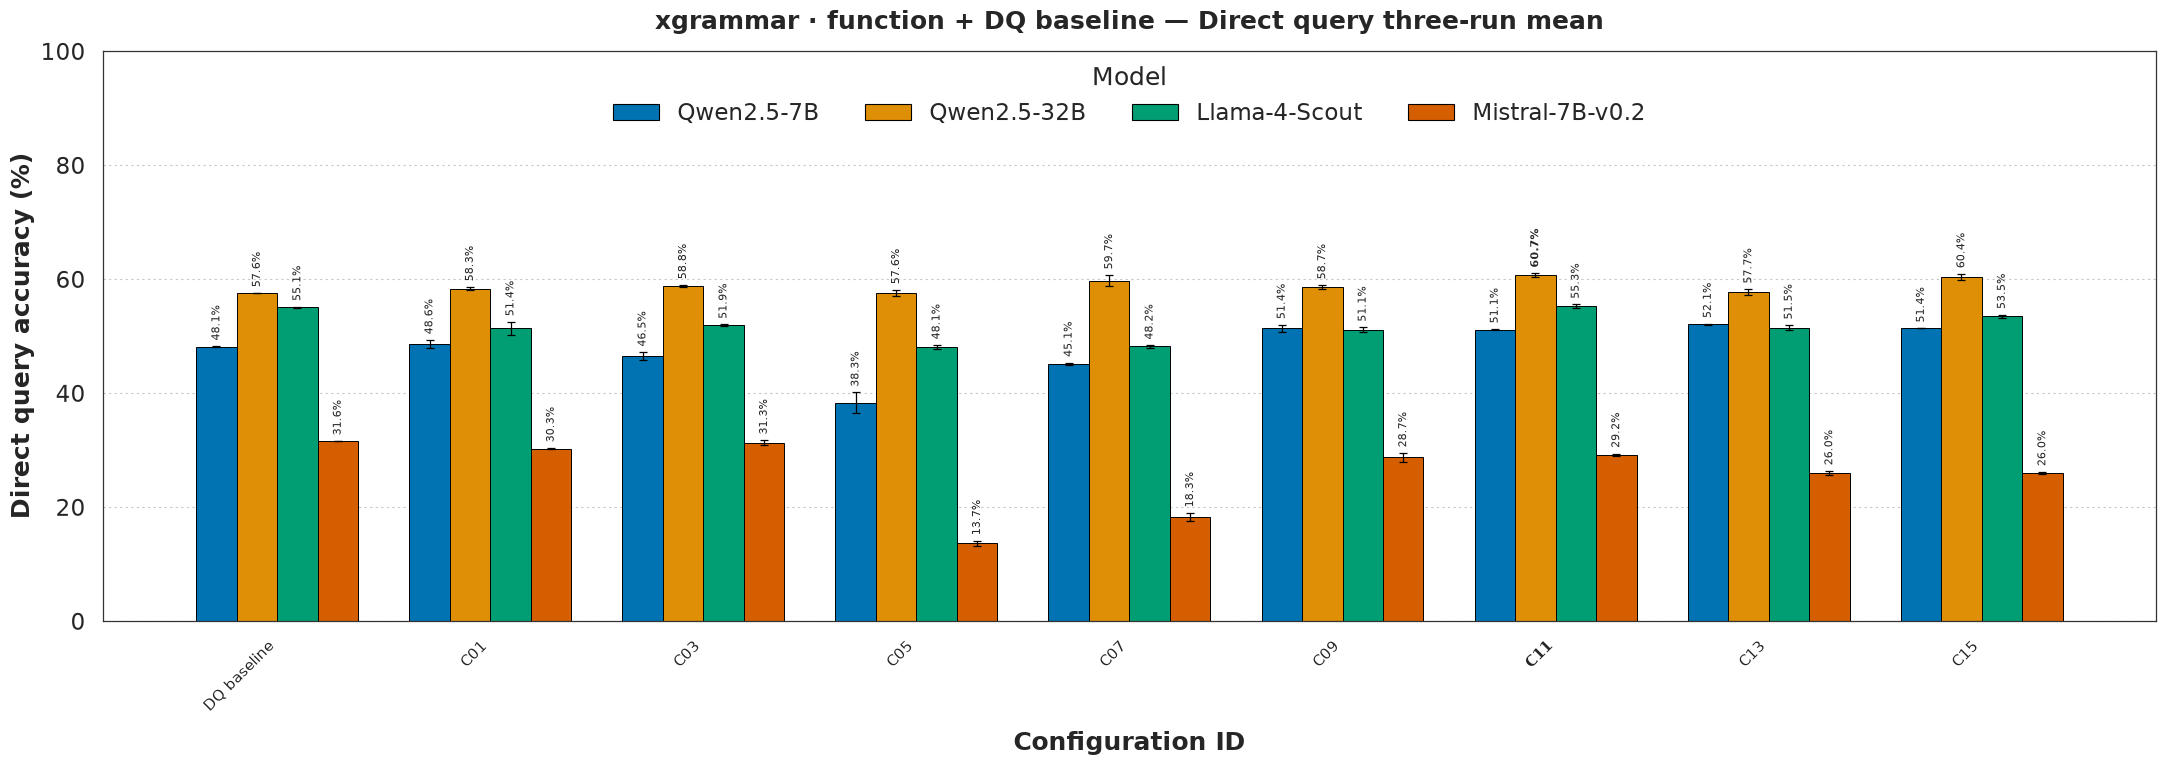

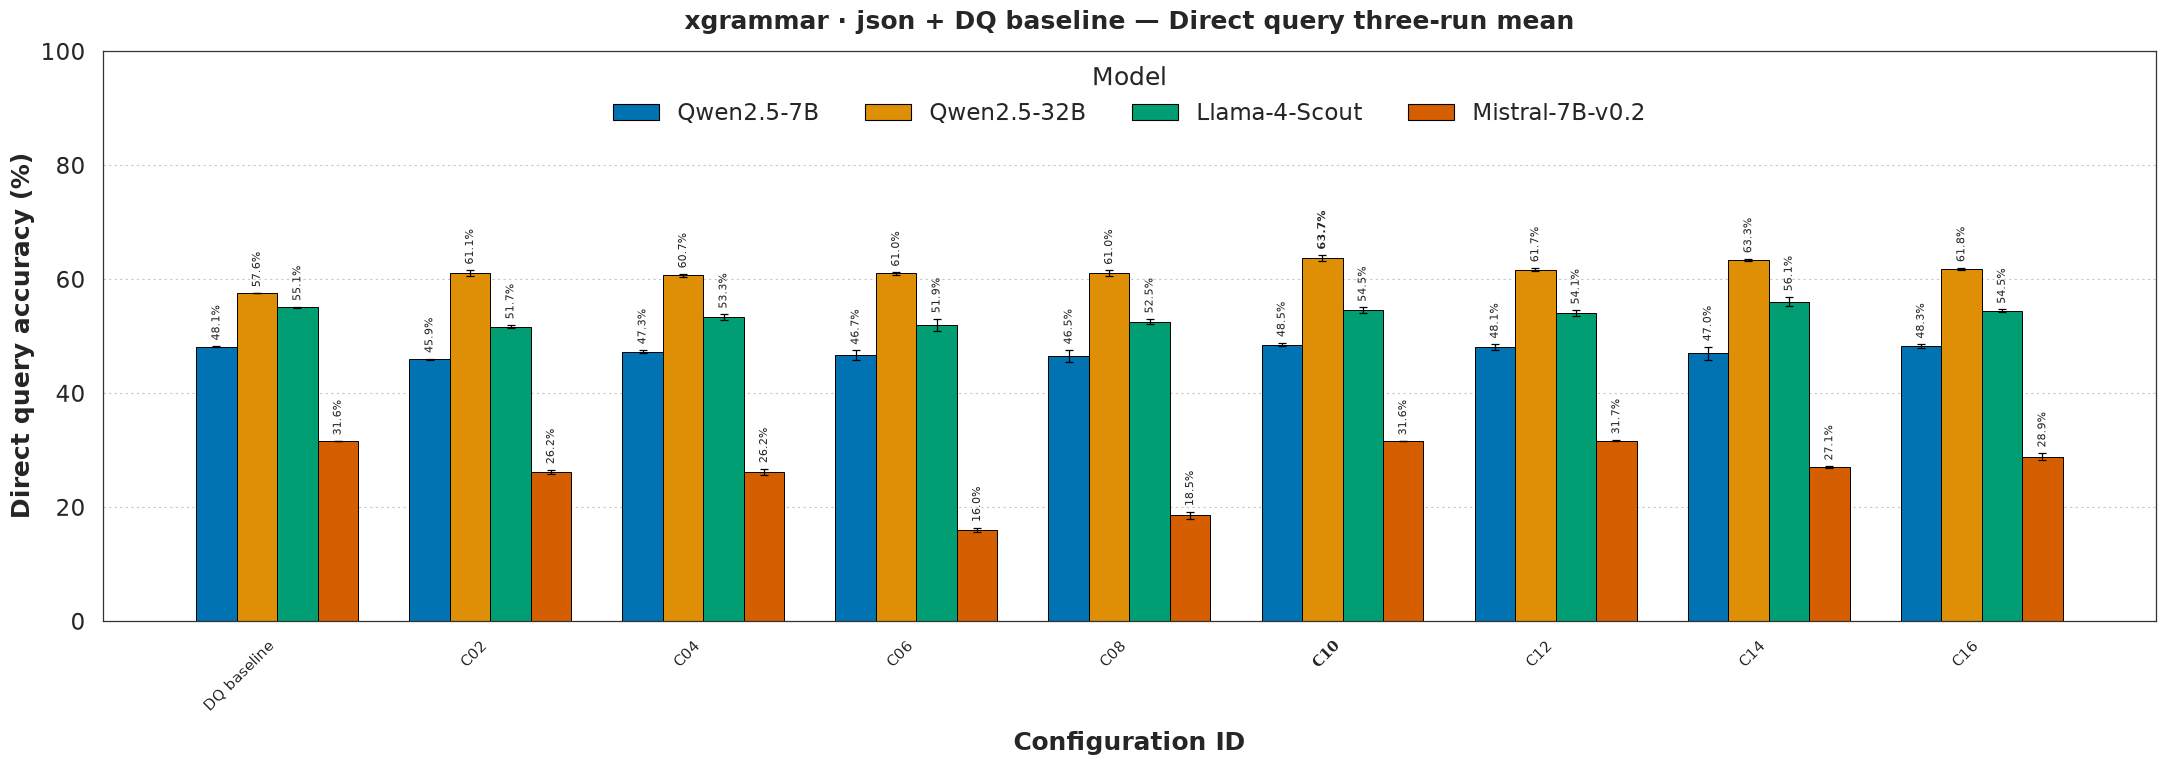

#### All configurations

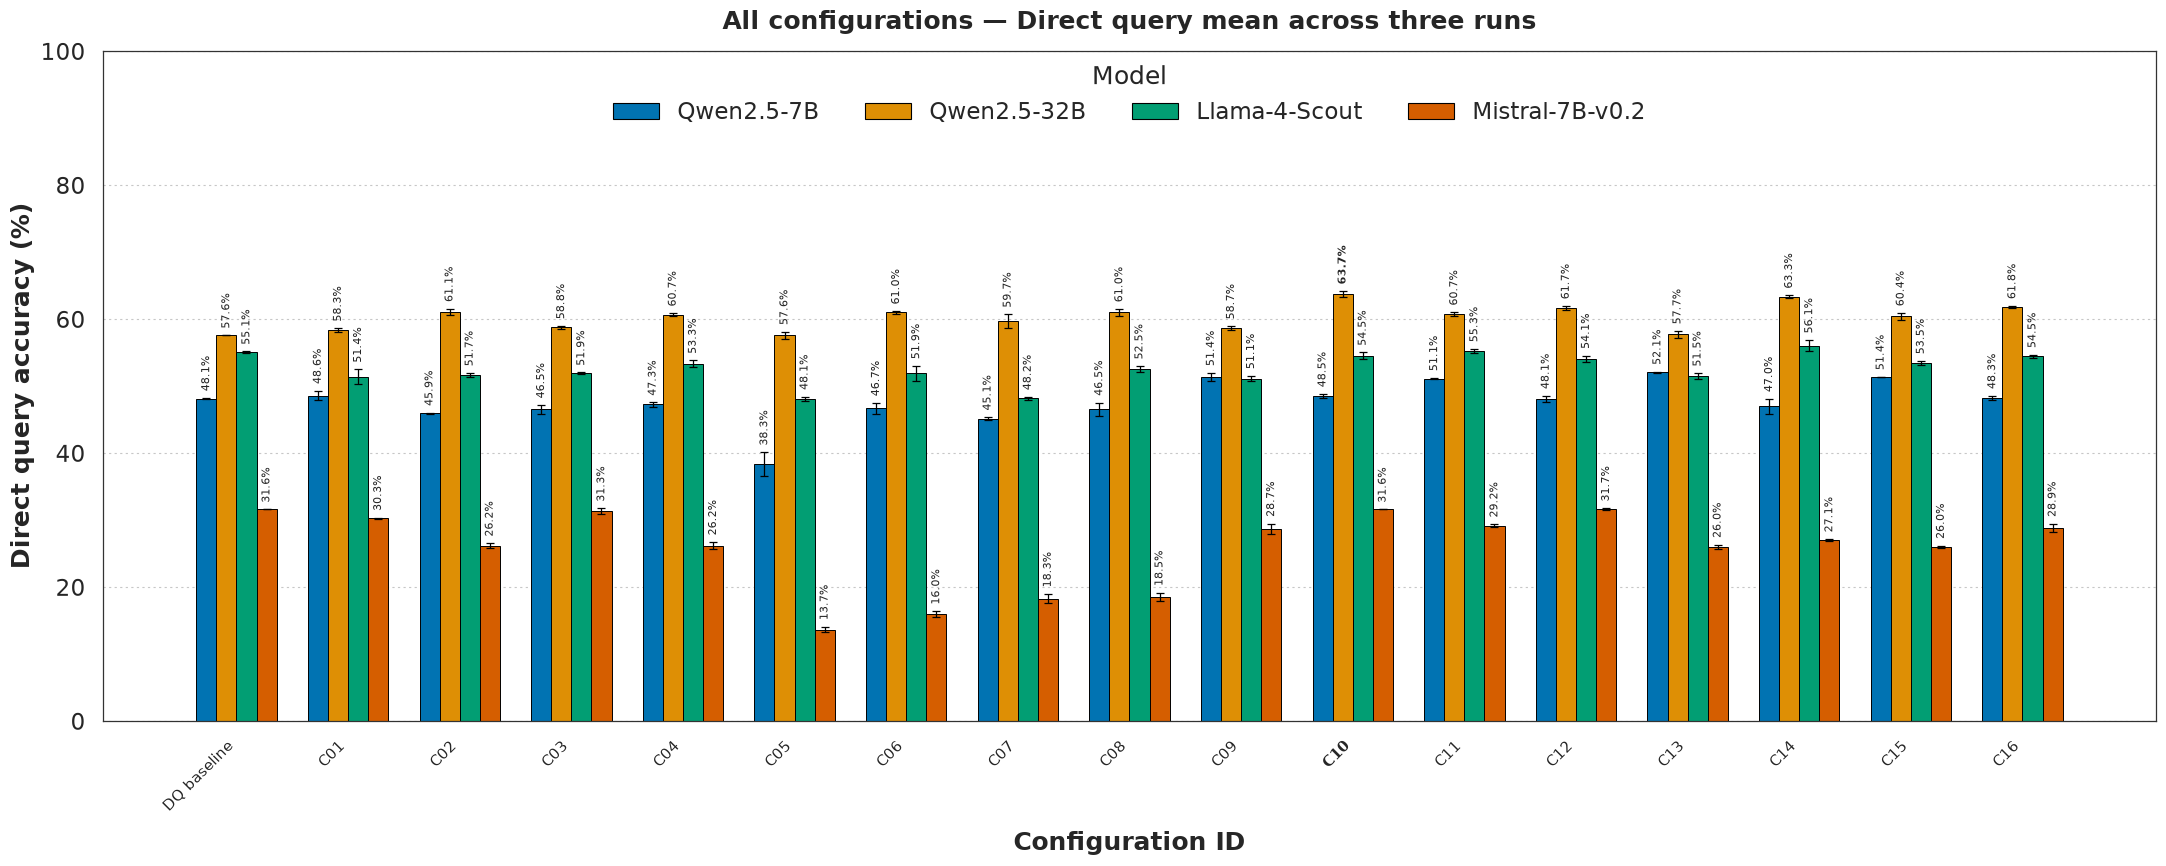

### NL-to-SQL

#### Per-model configurations

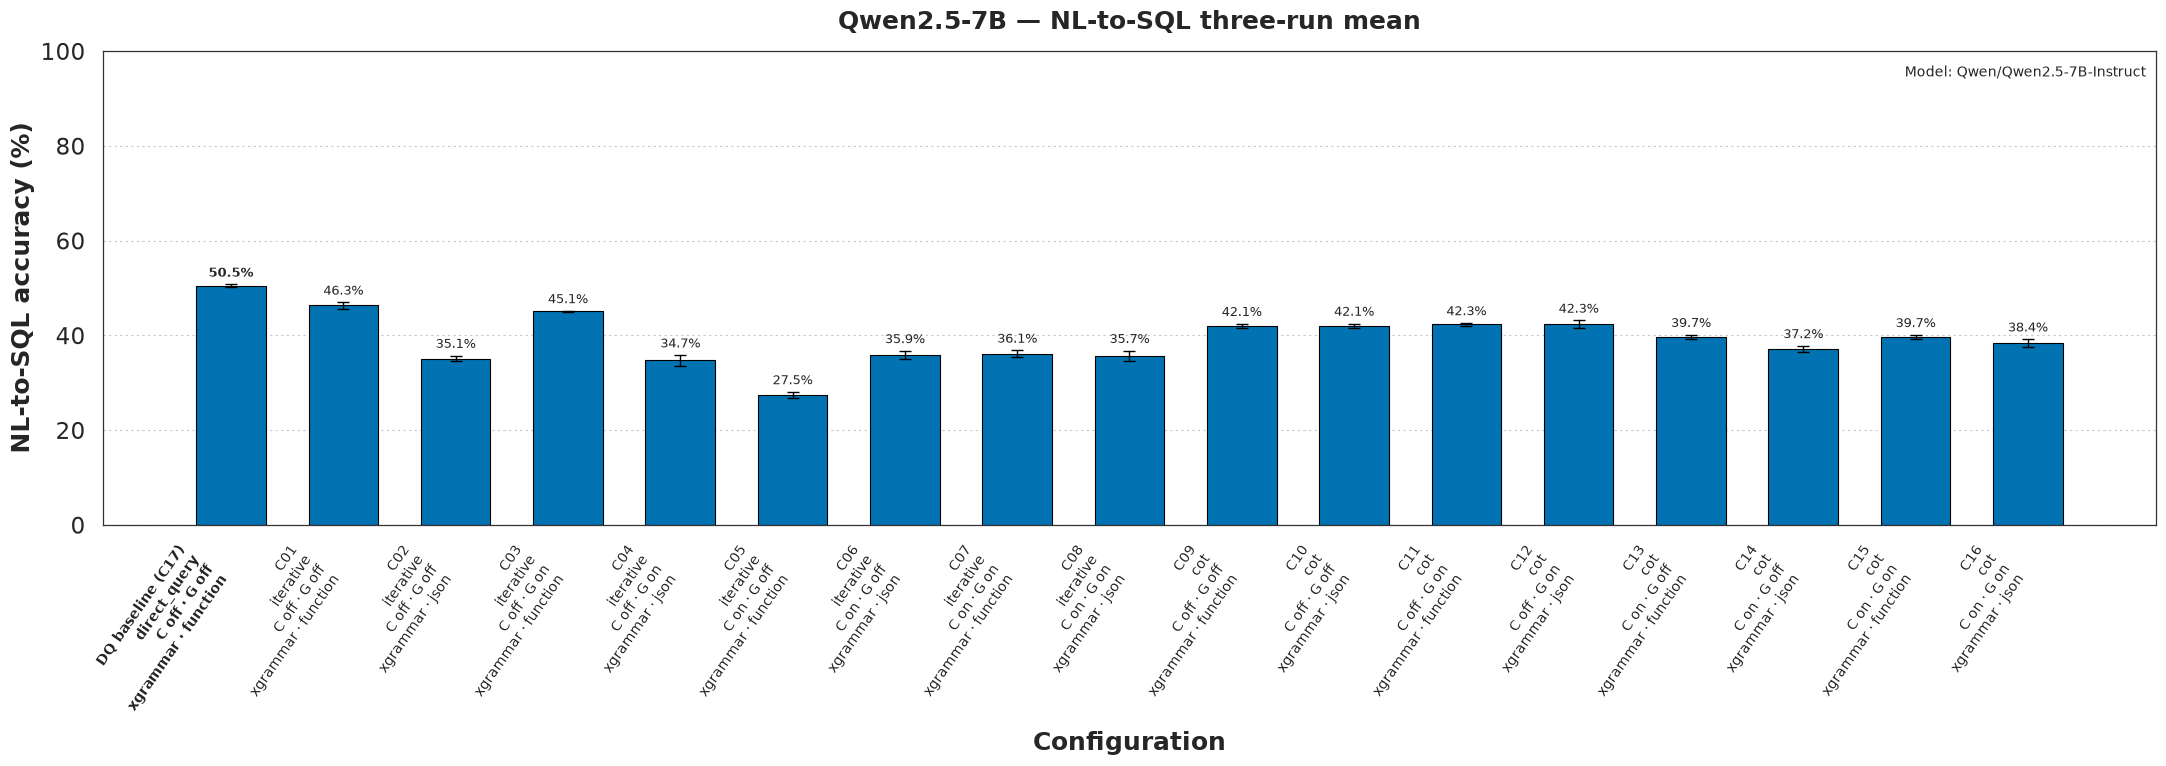

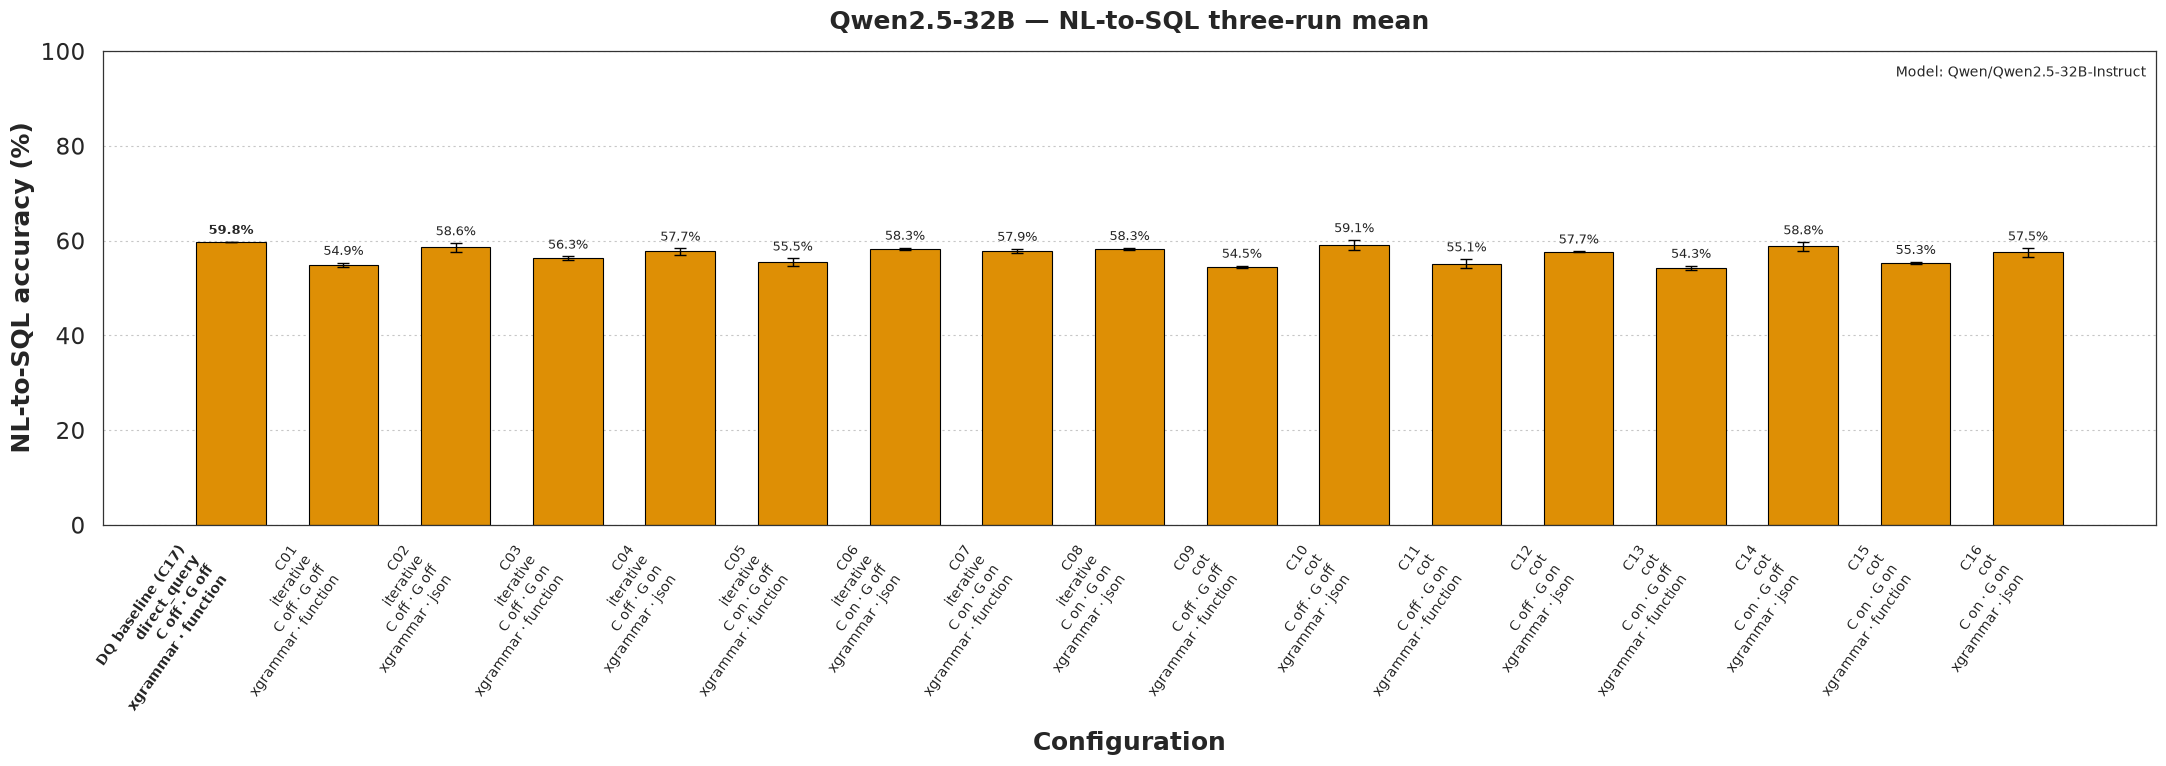

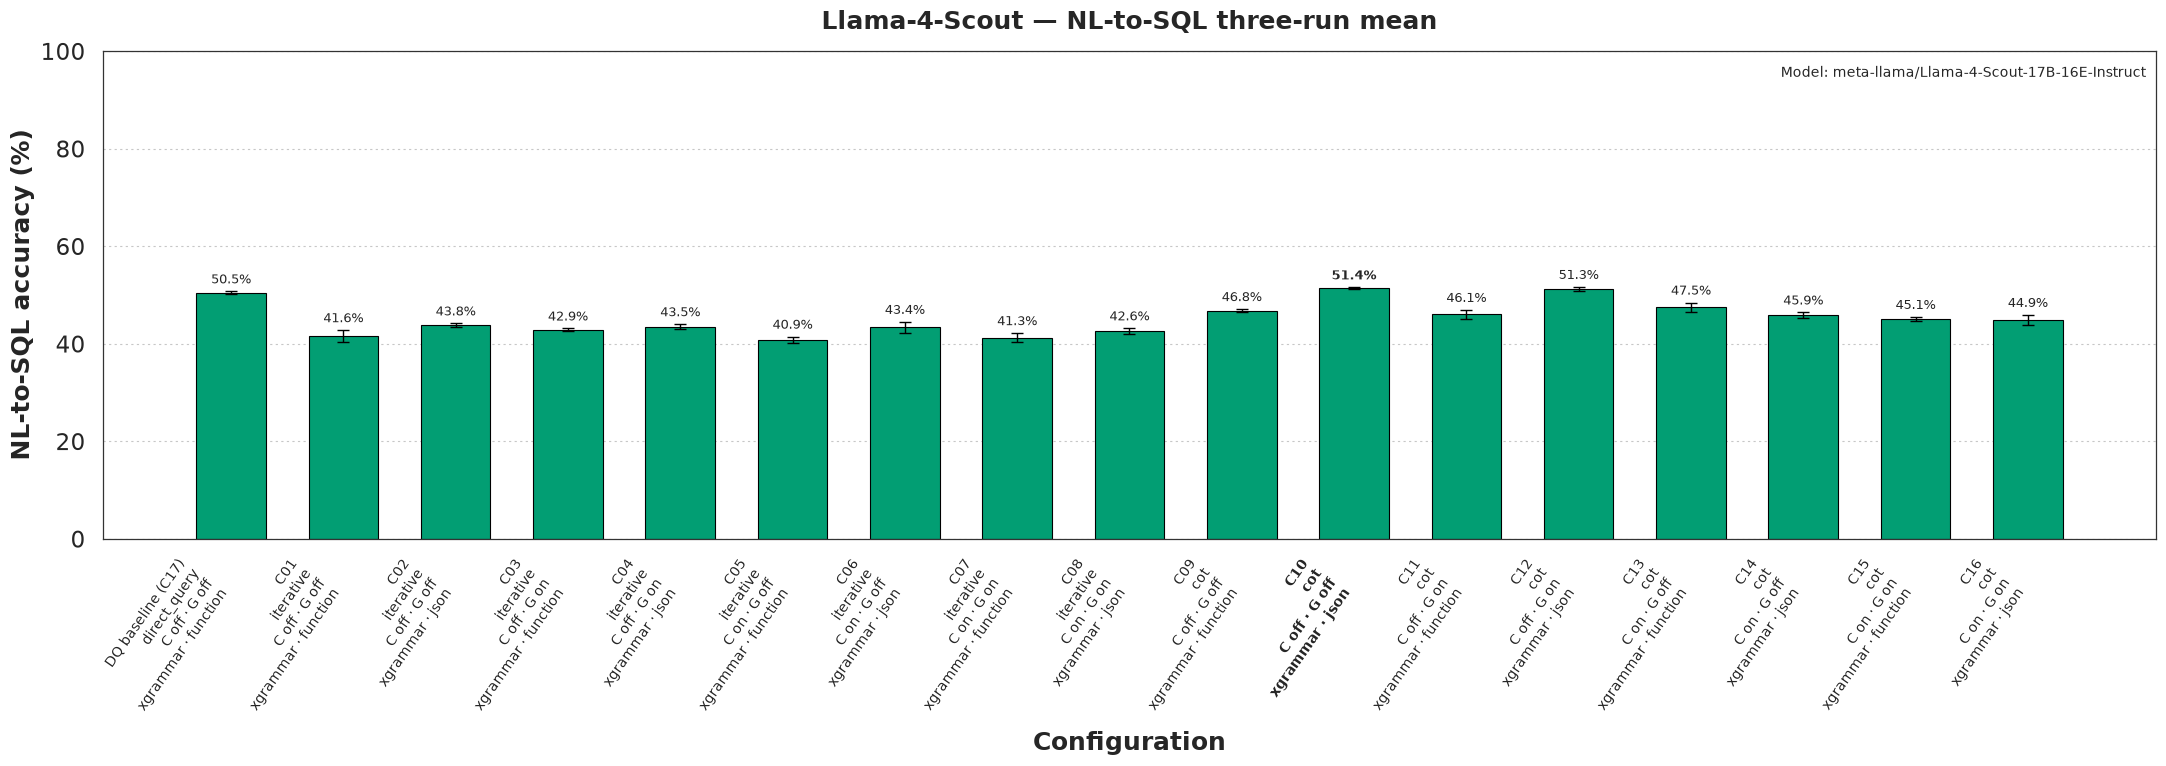

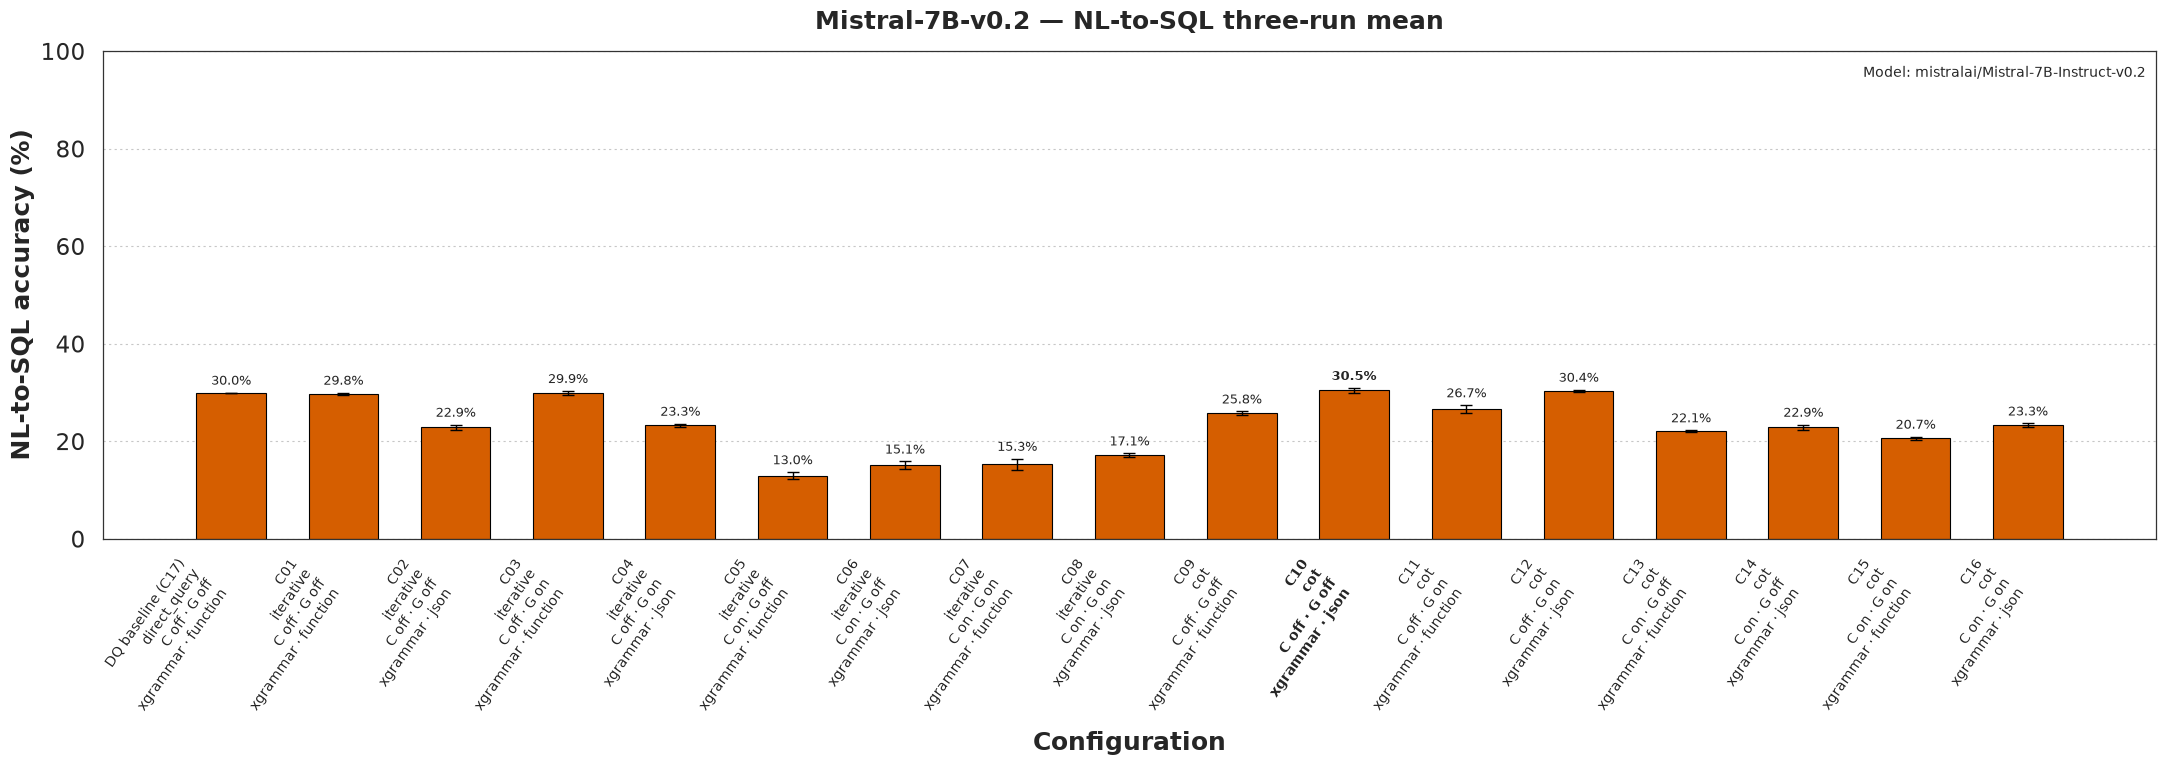

#### Per-experiment-category comparisons

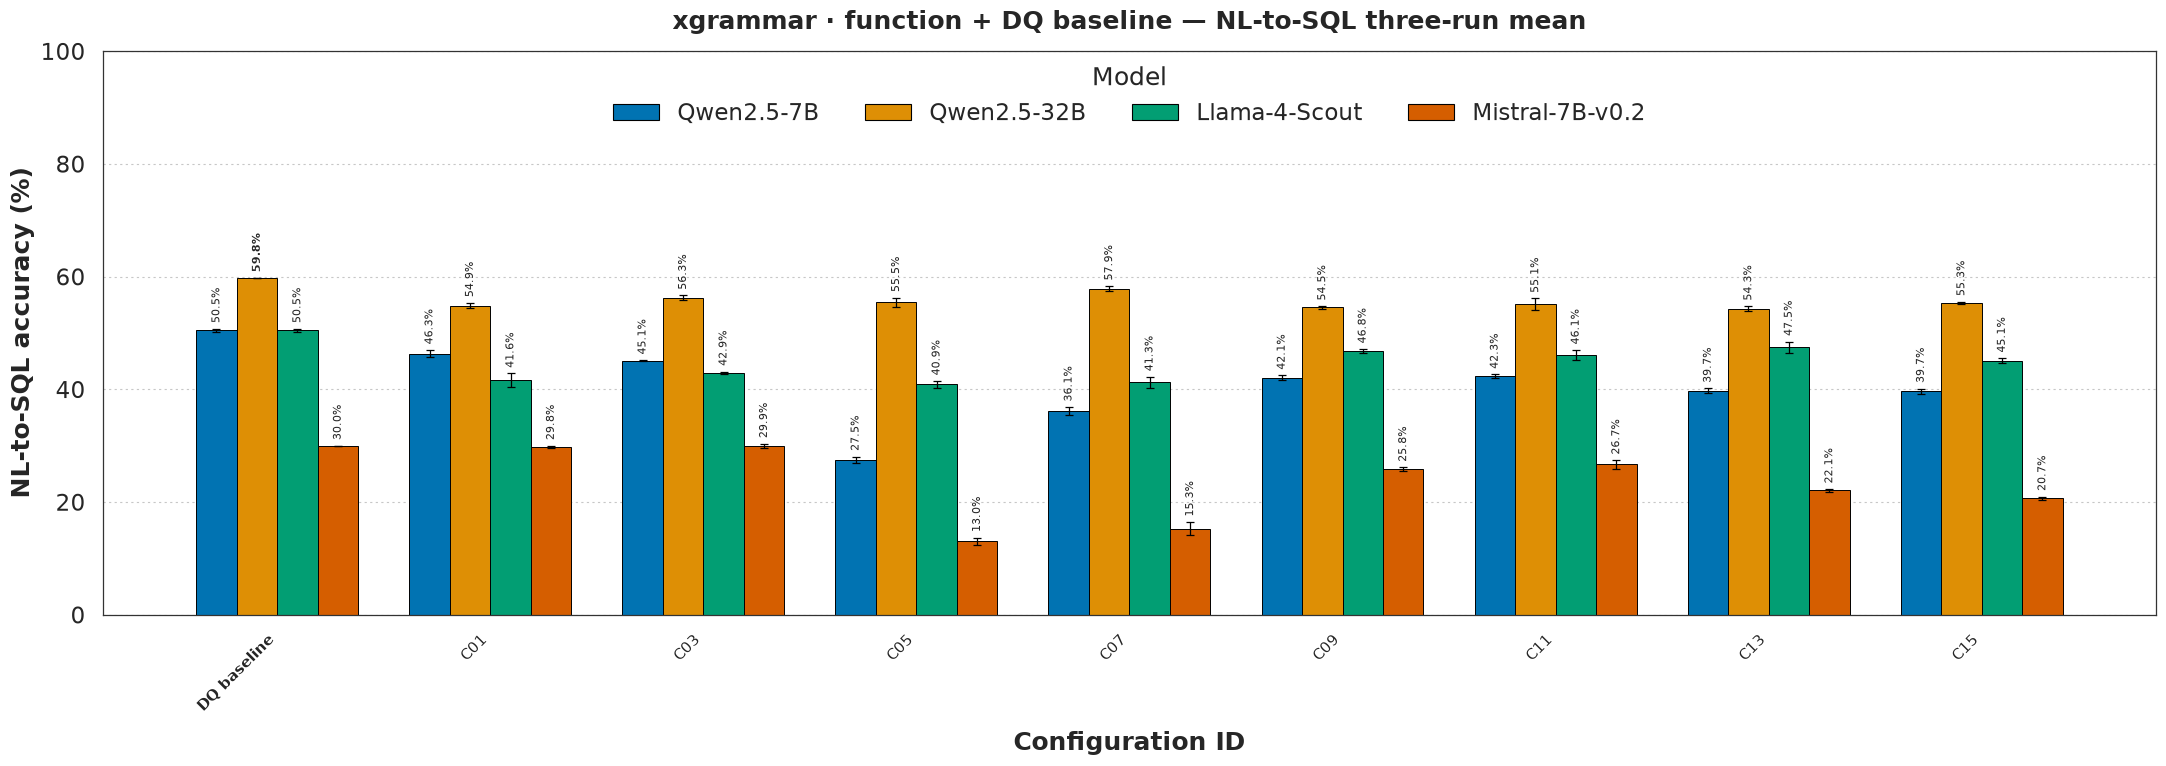

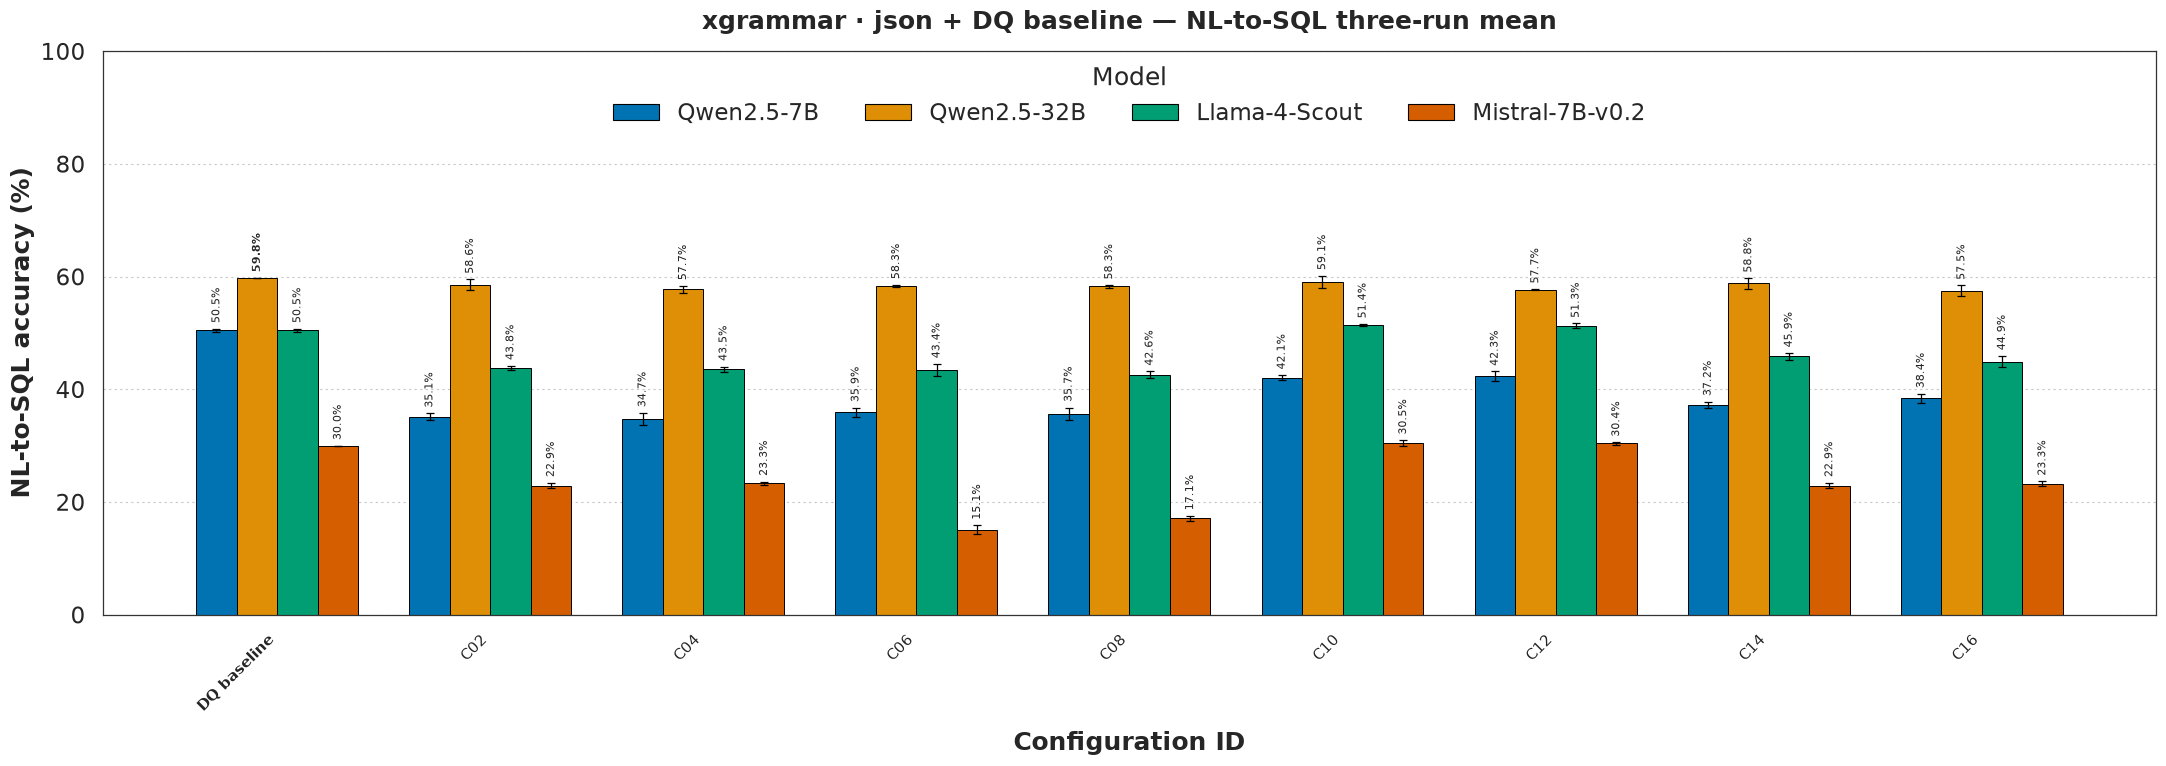

#### All configurations

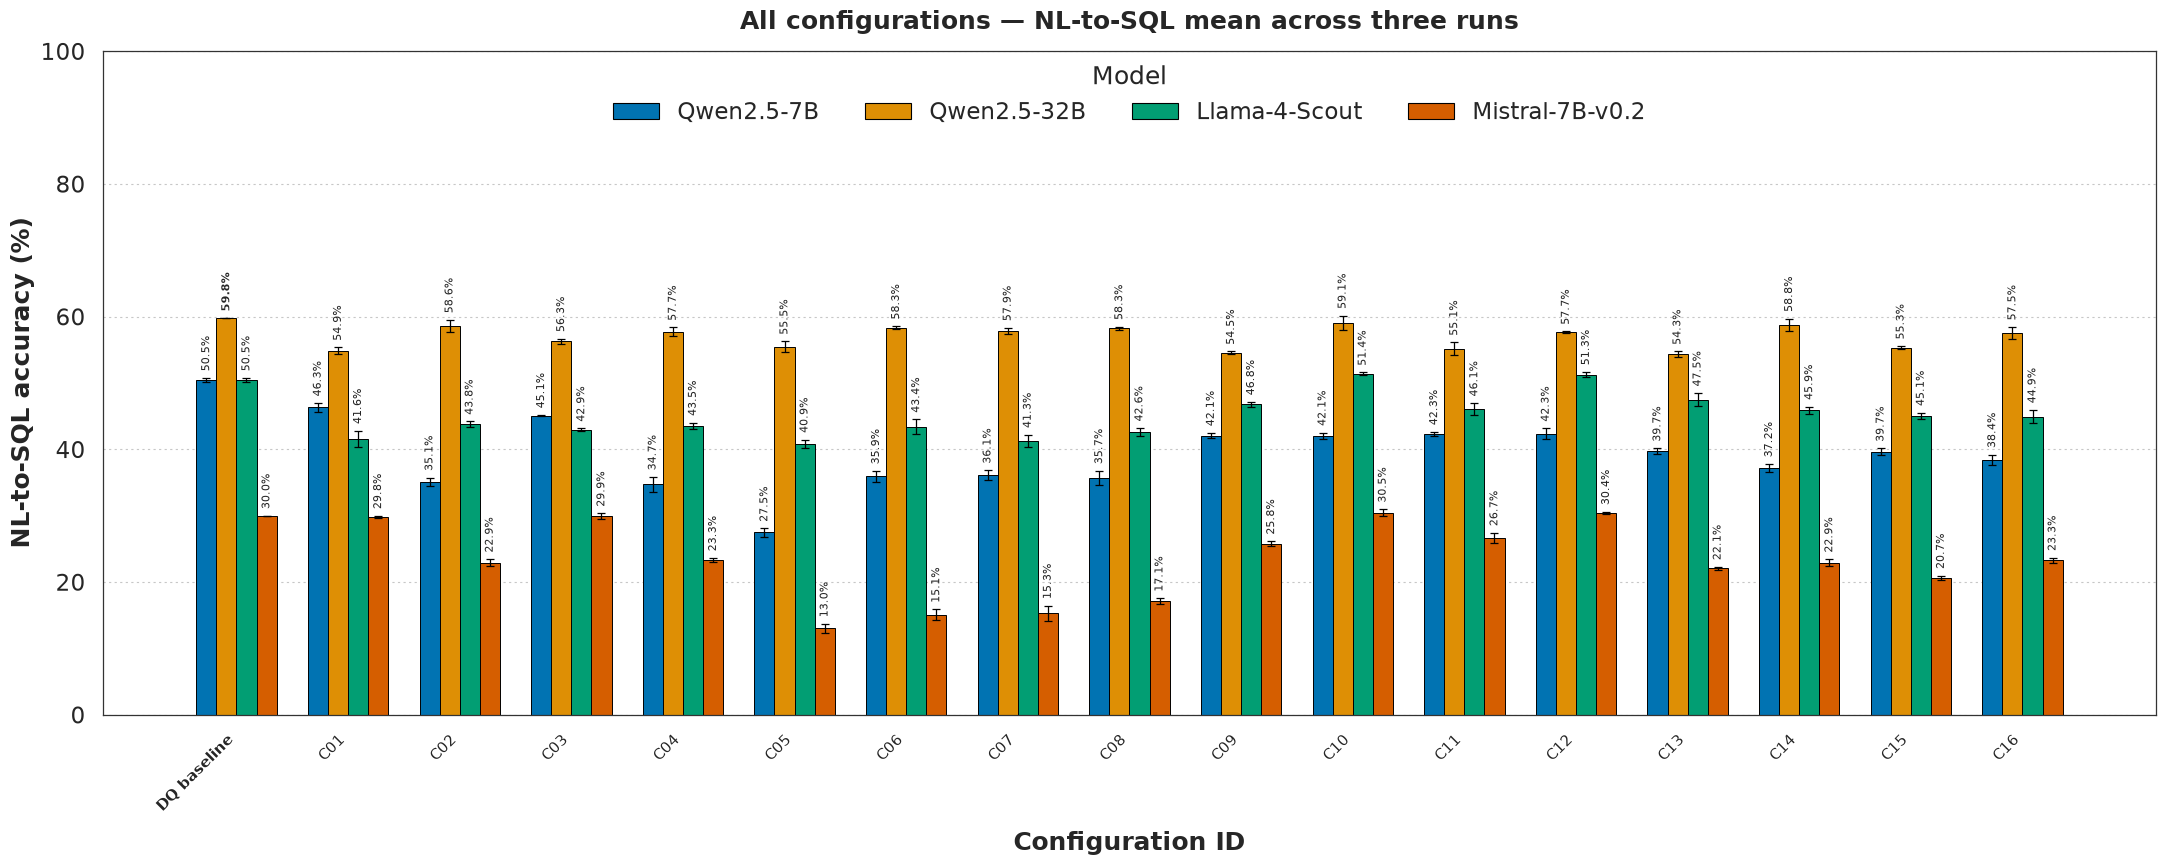

### NL-to-code

#### Per-model configurations

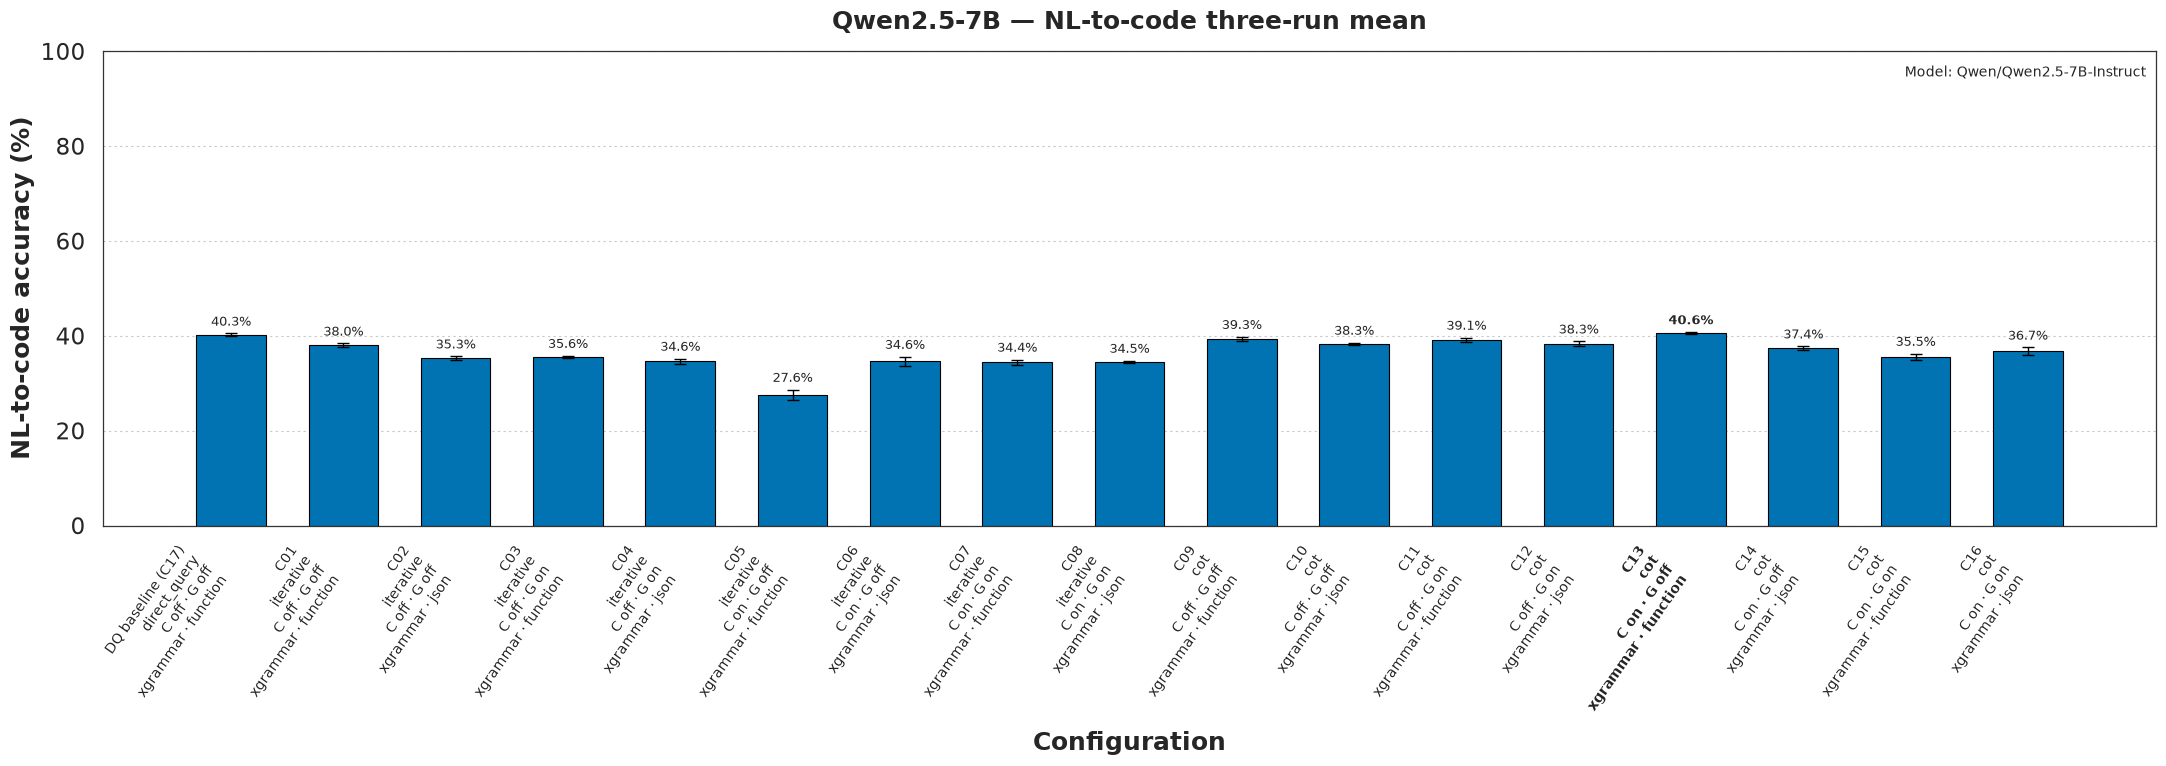

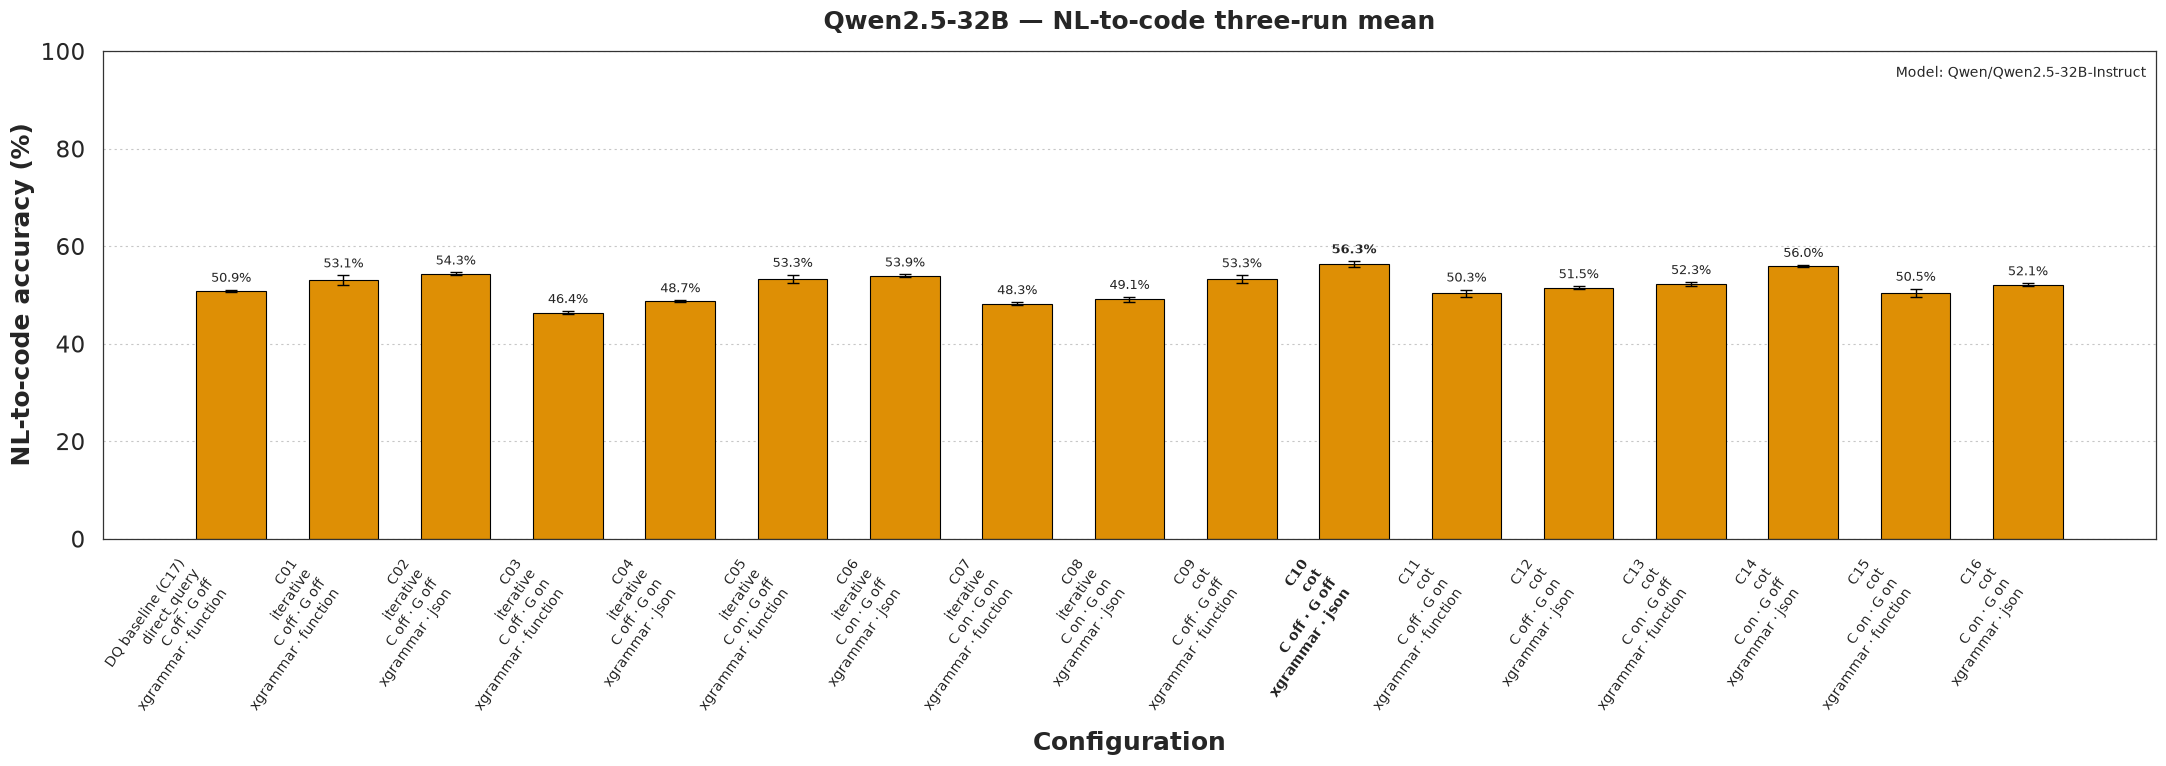

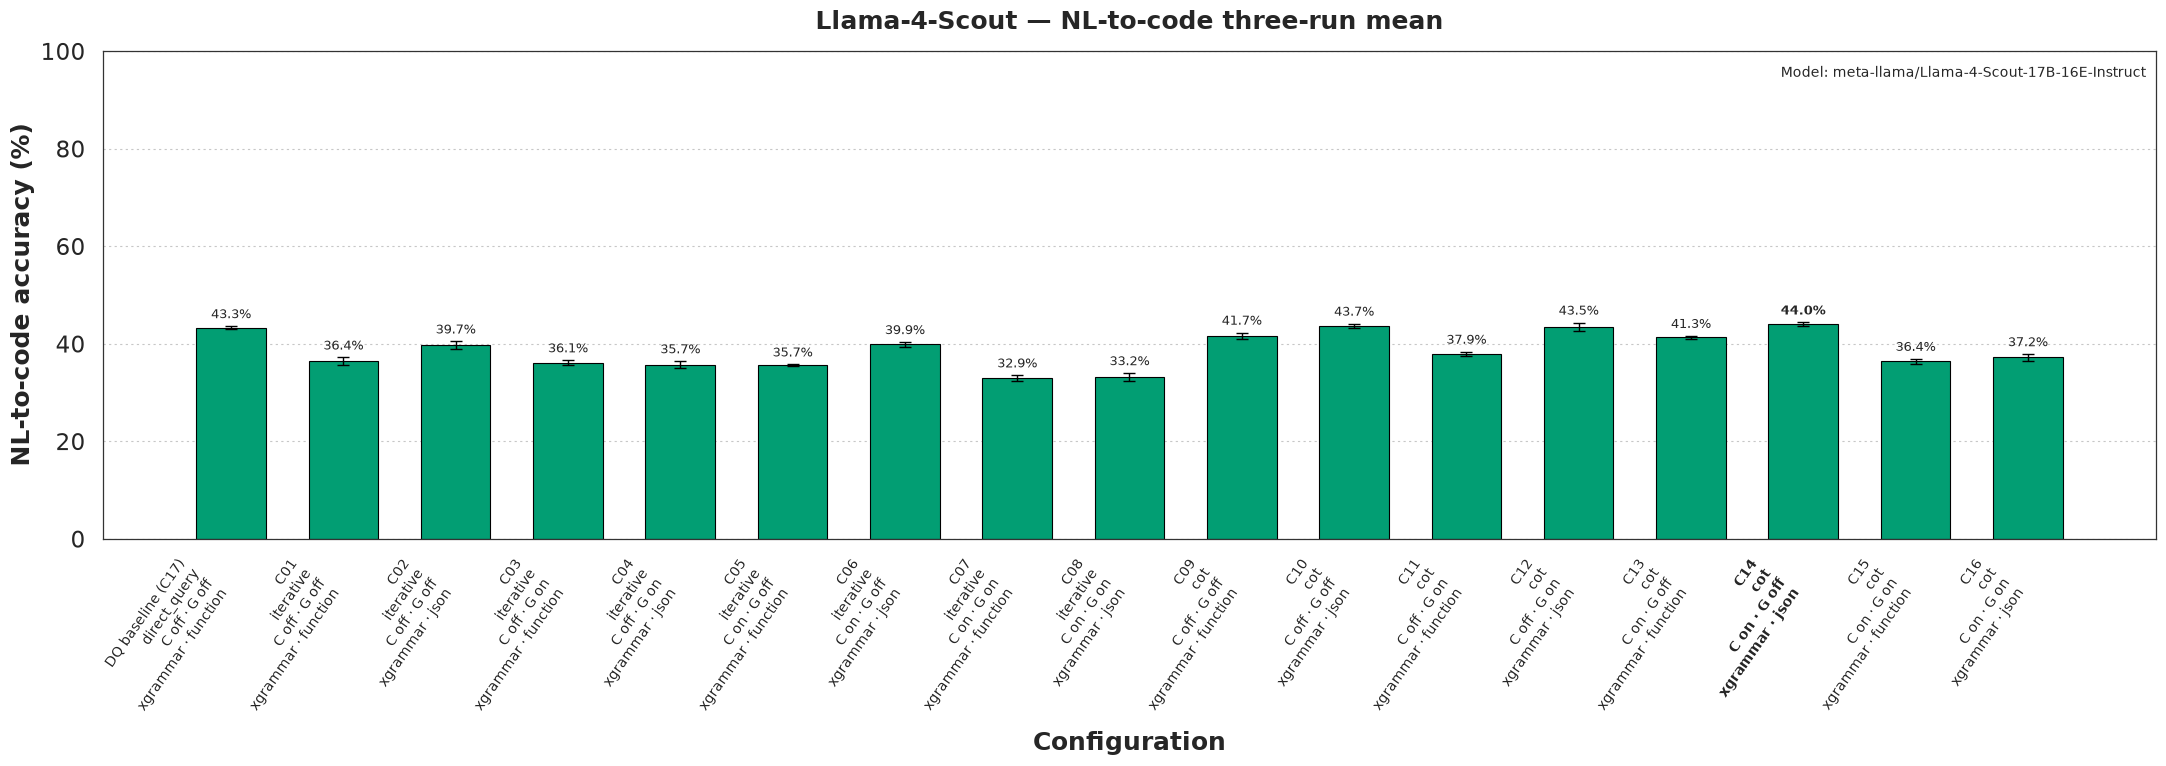

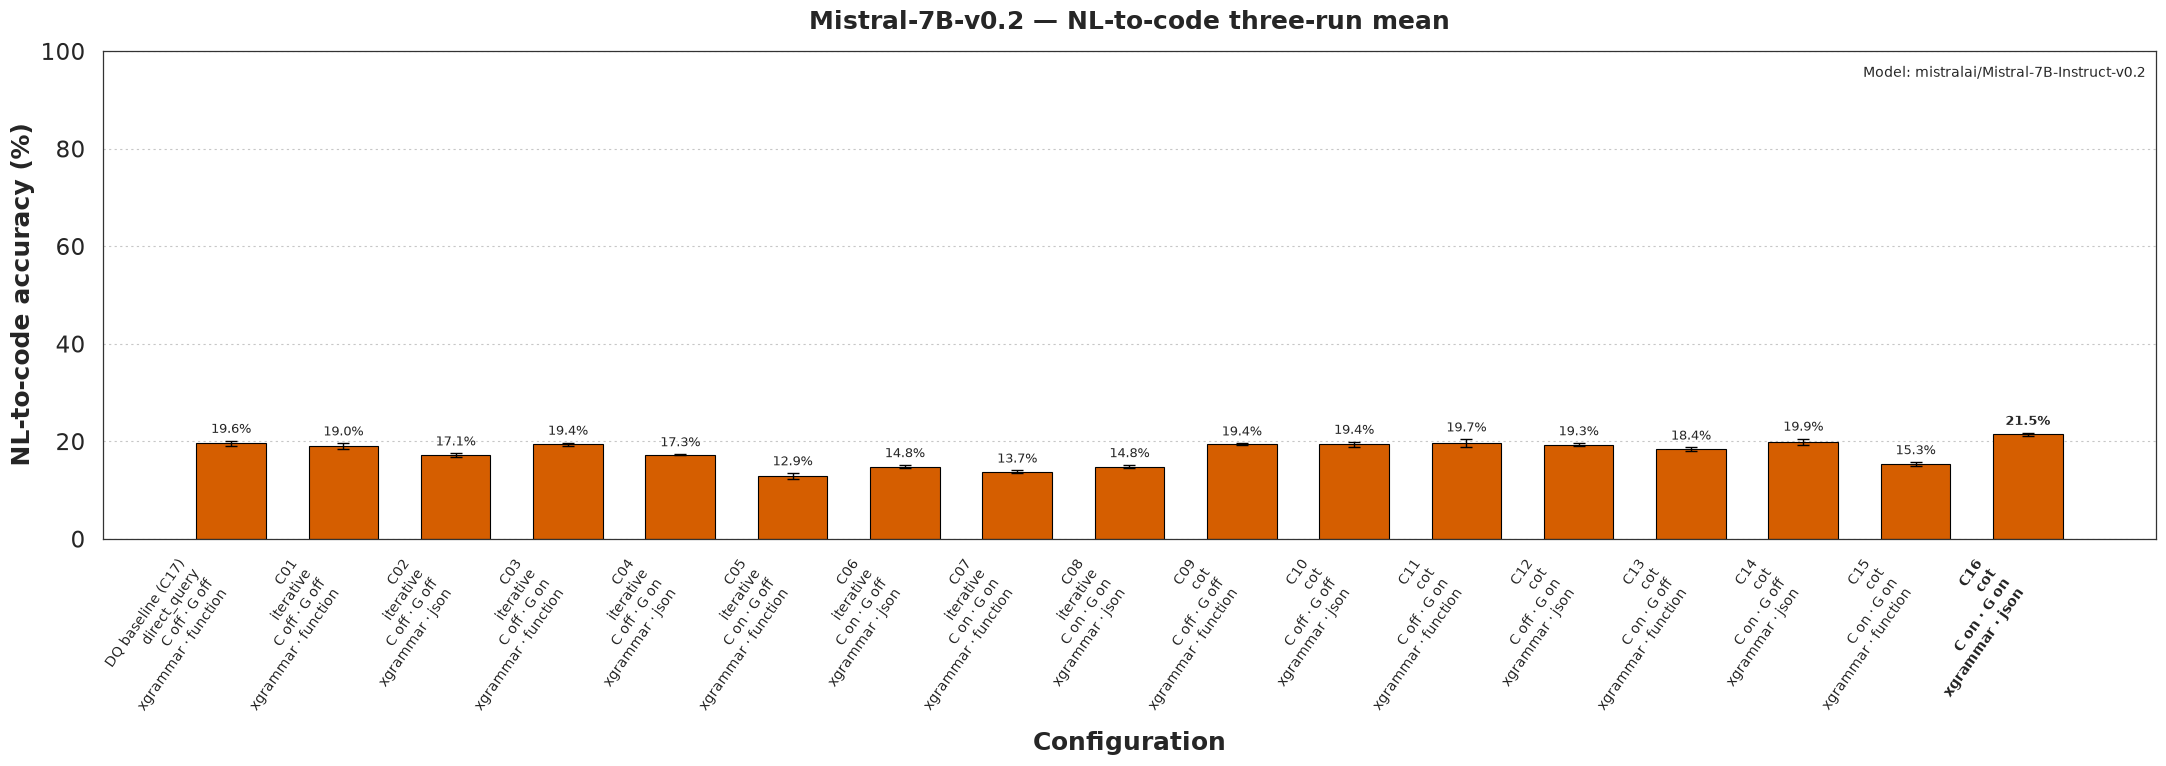

#### Per-experiment-category comparisons

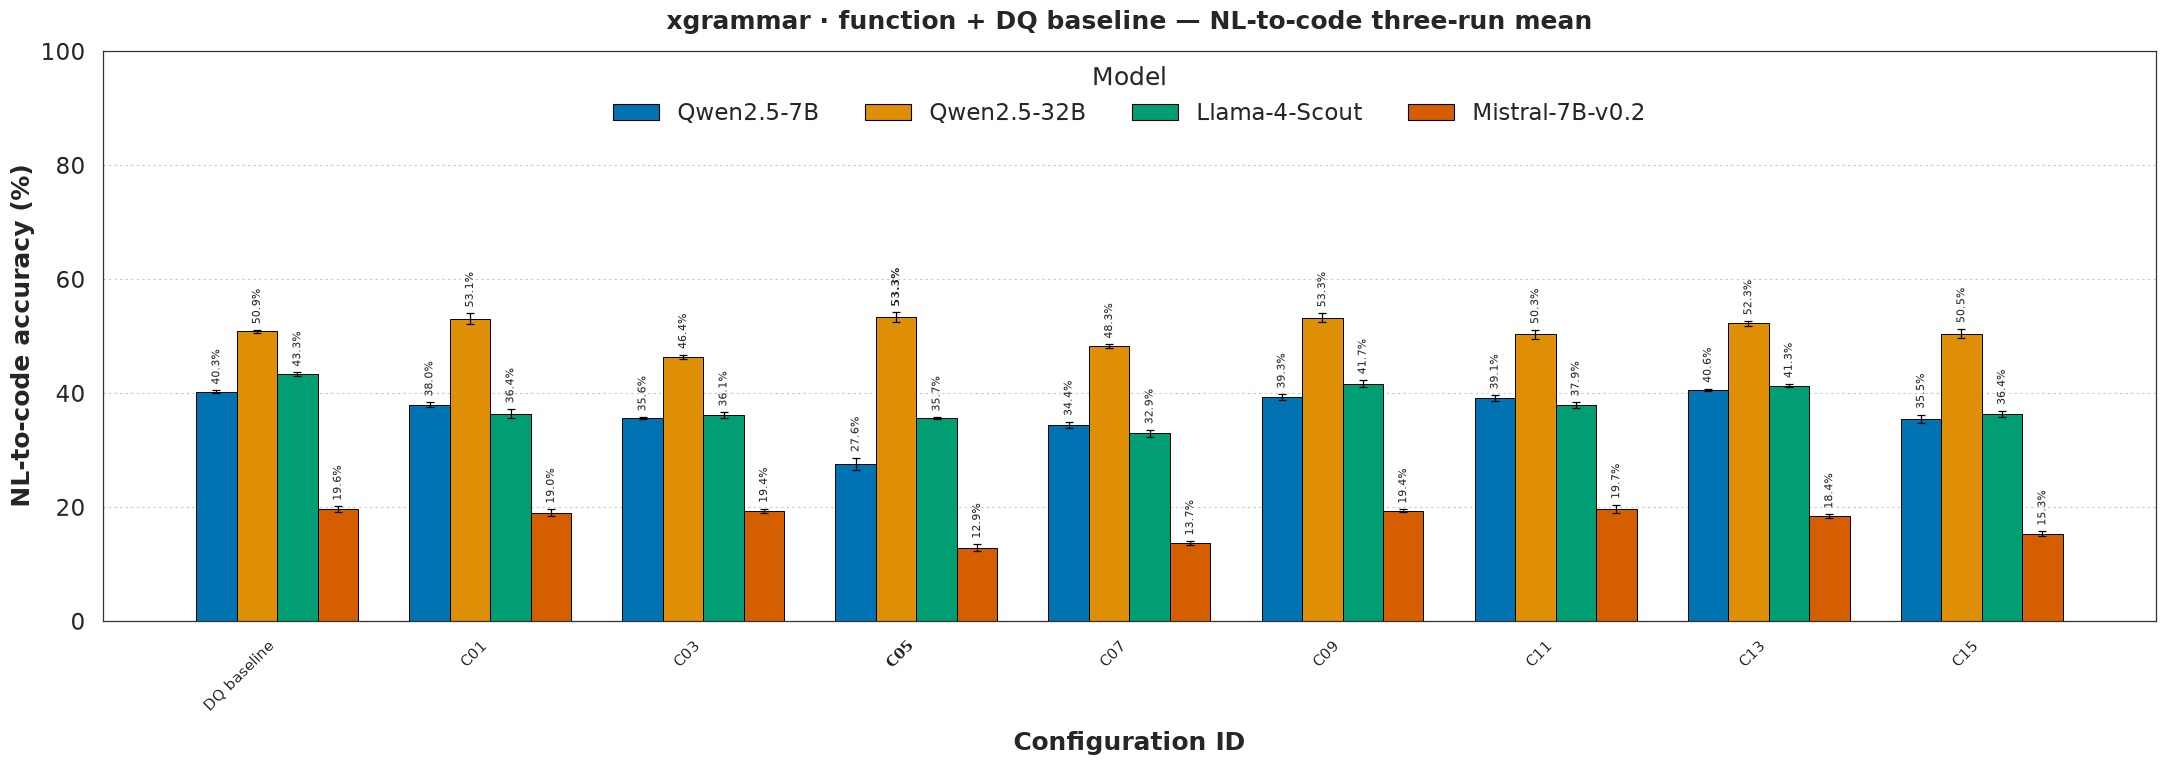

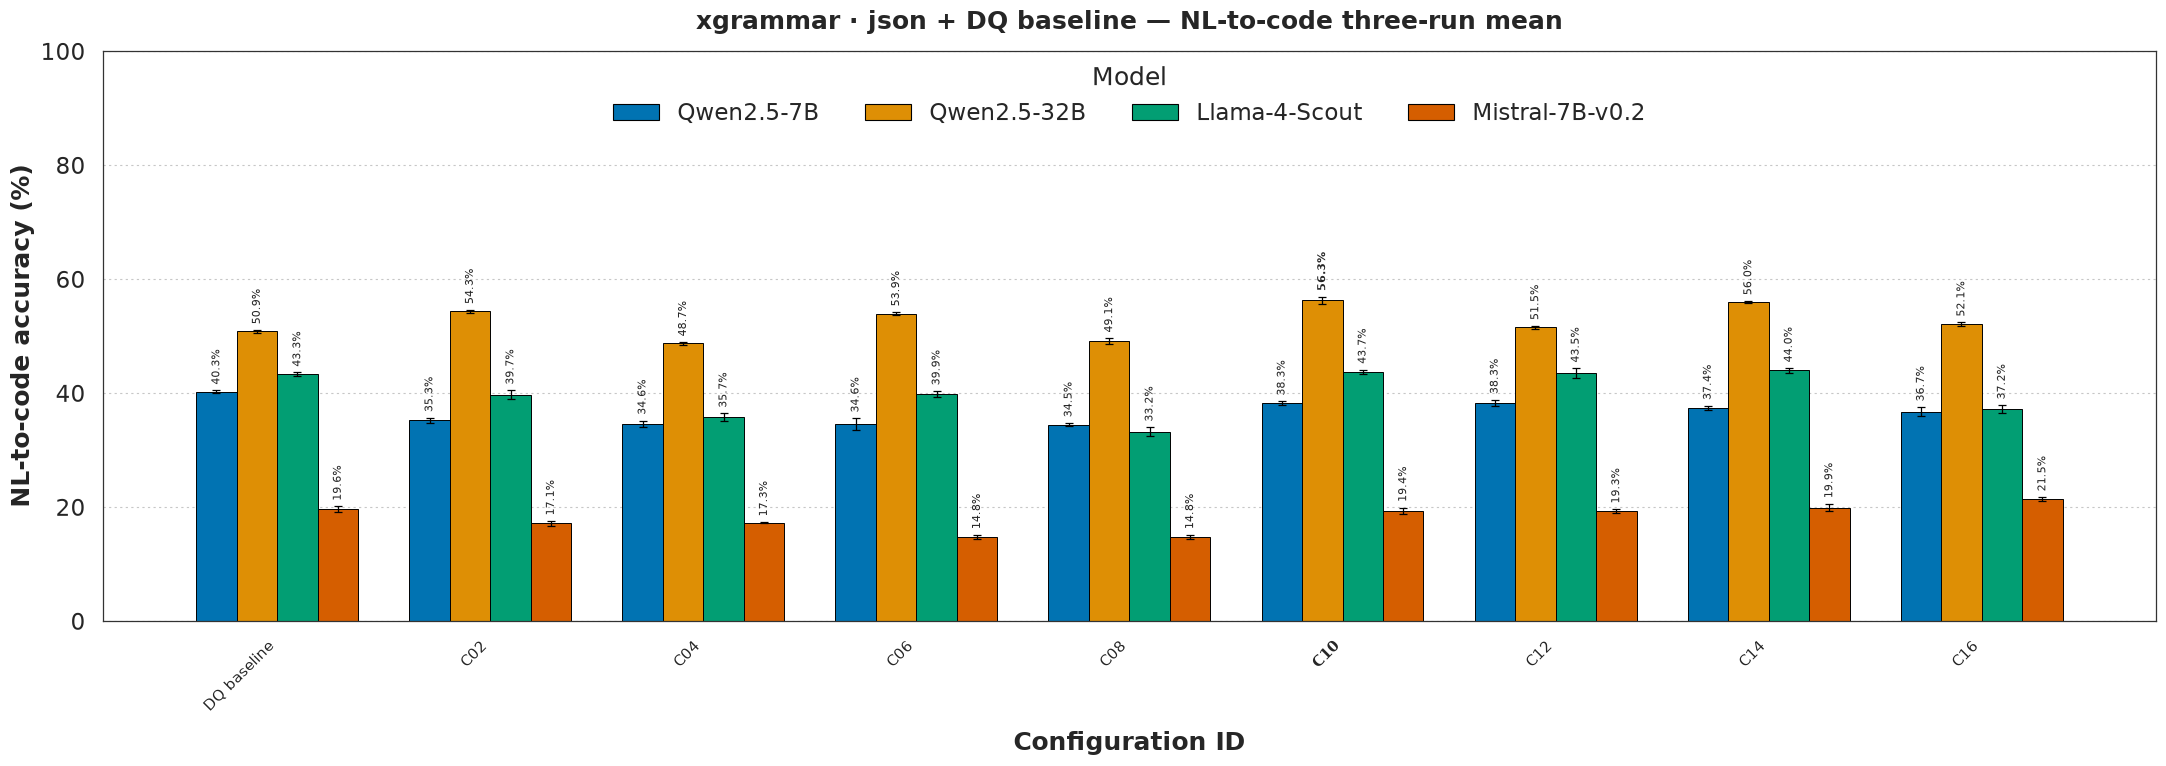

#### All configurations

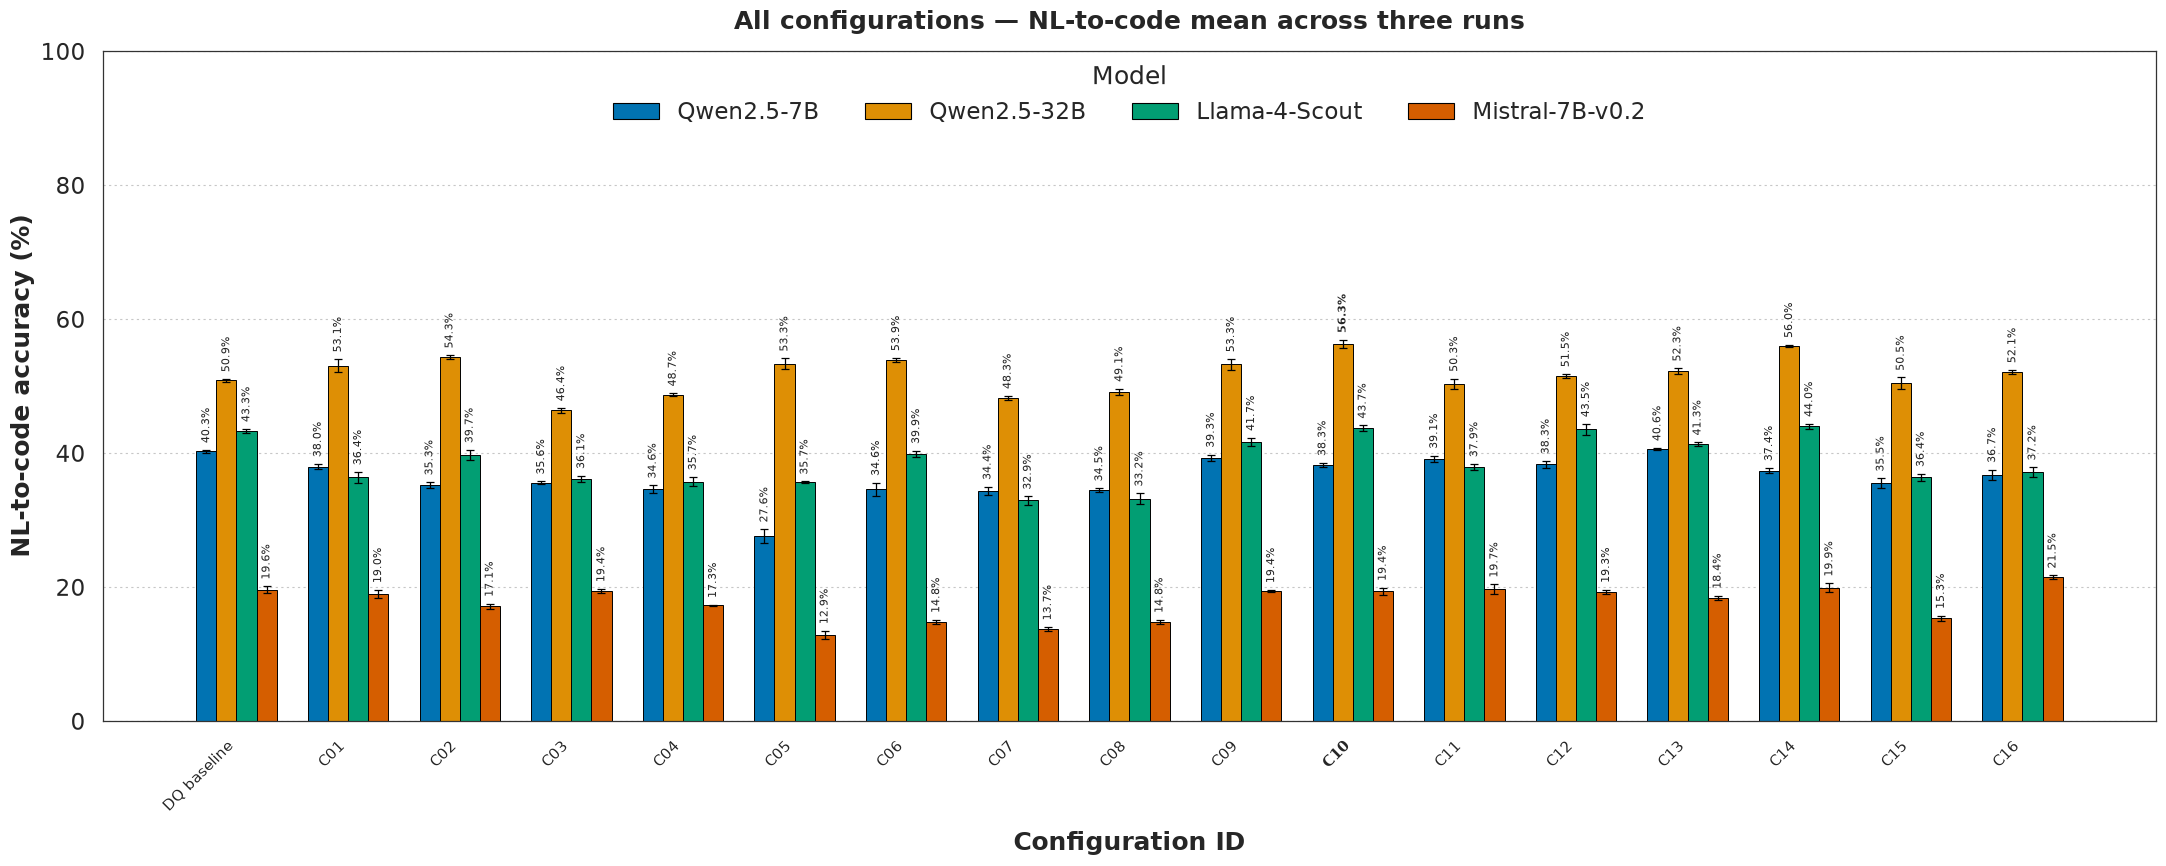

### End-to-ender

#### Per-model configurations

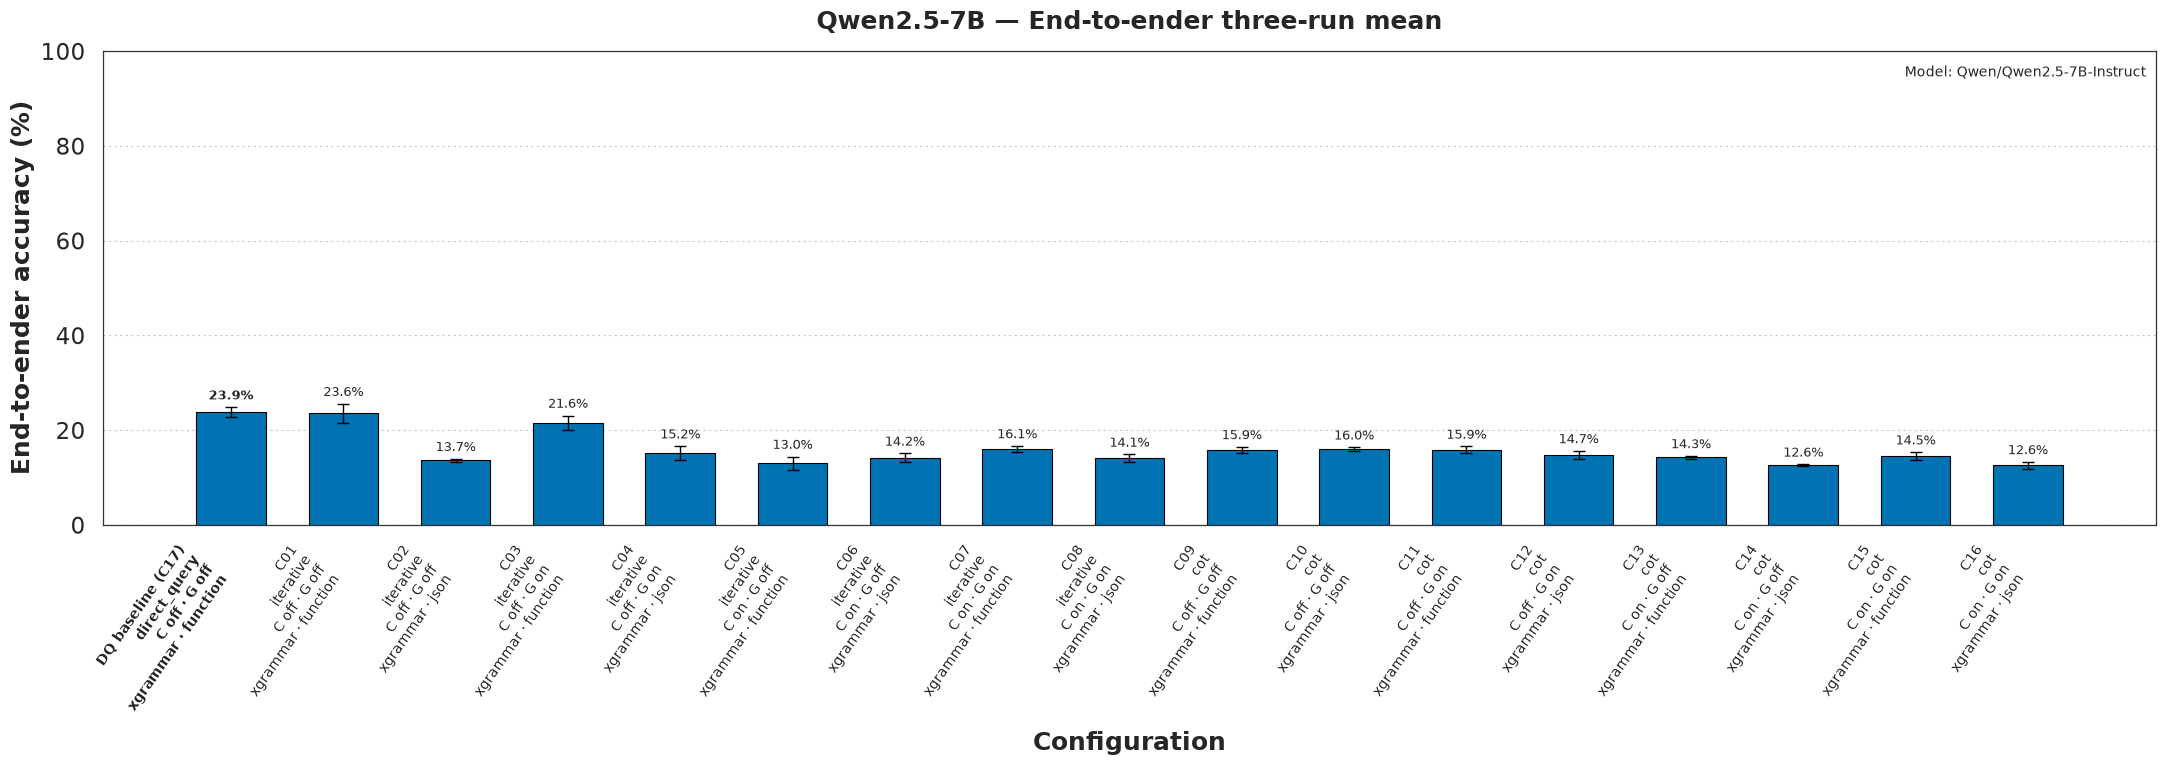

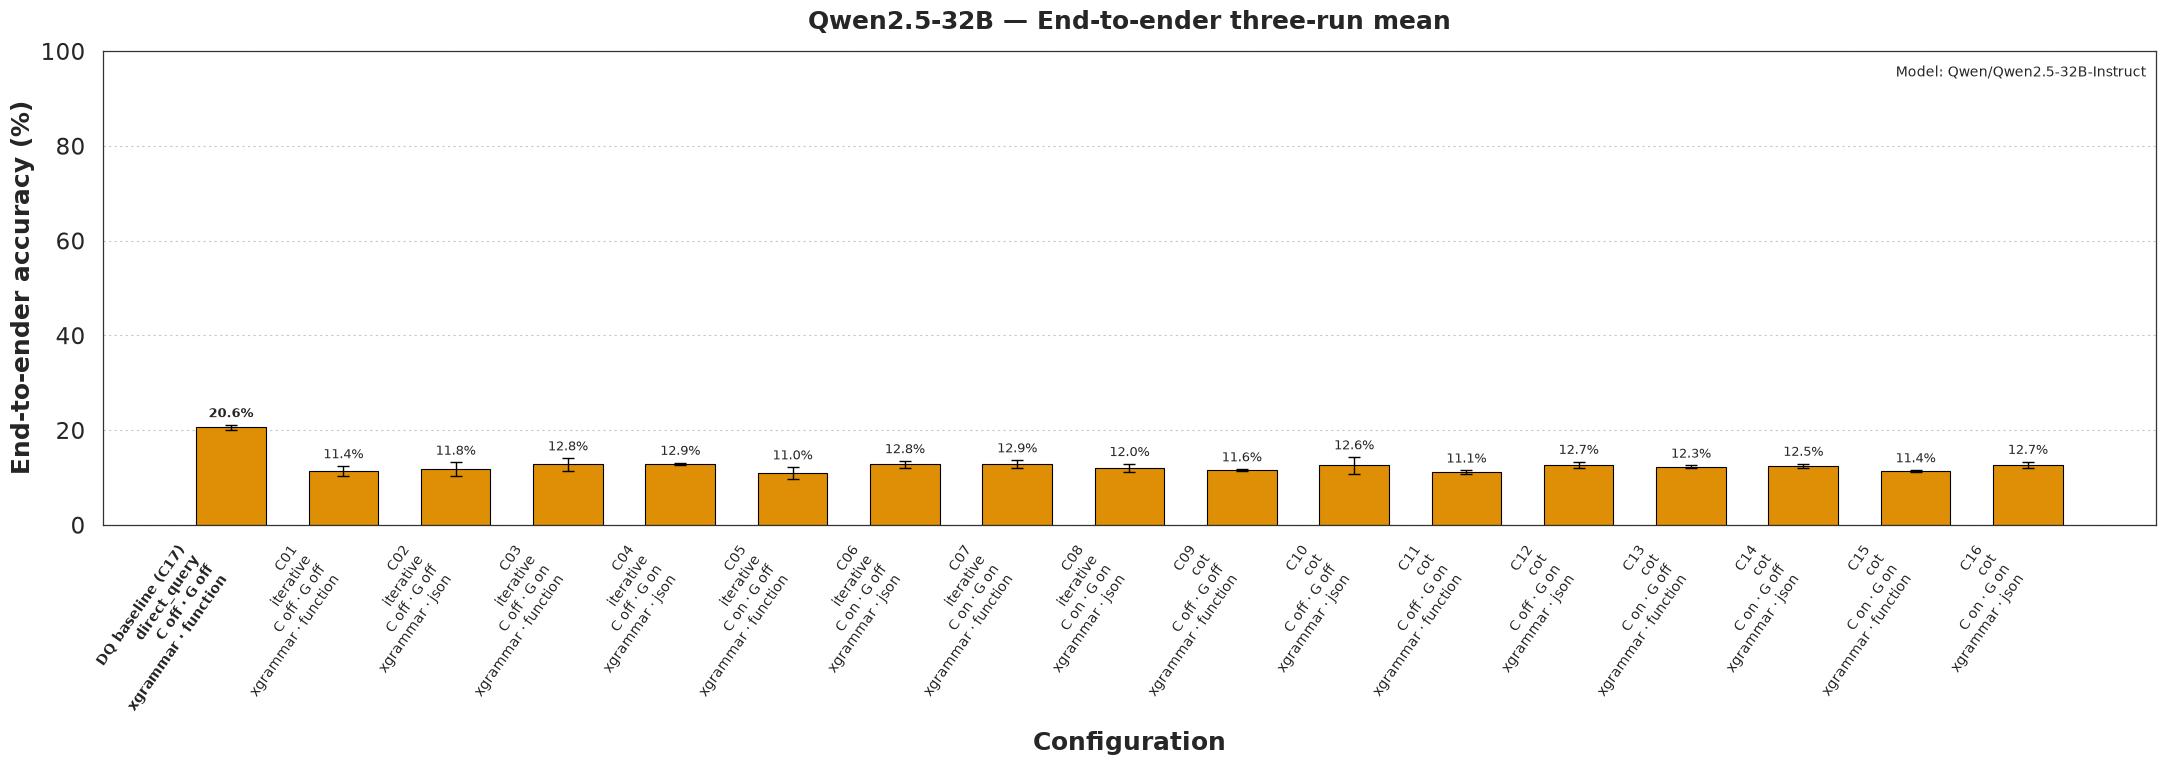

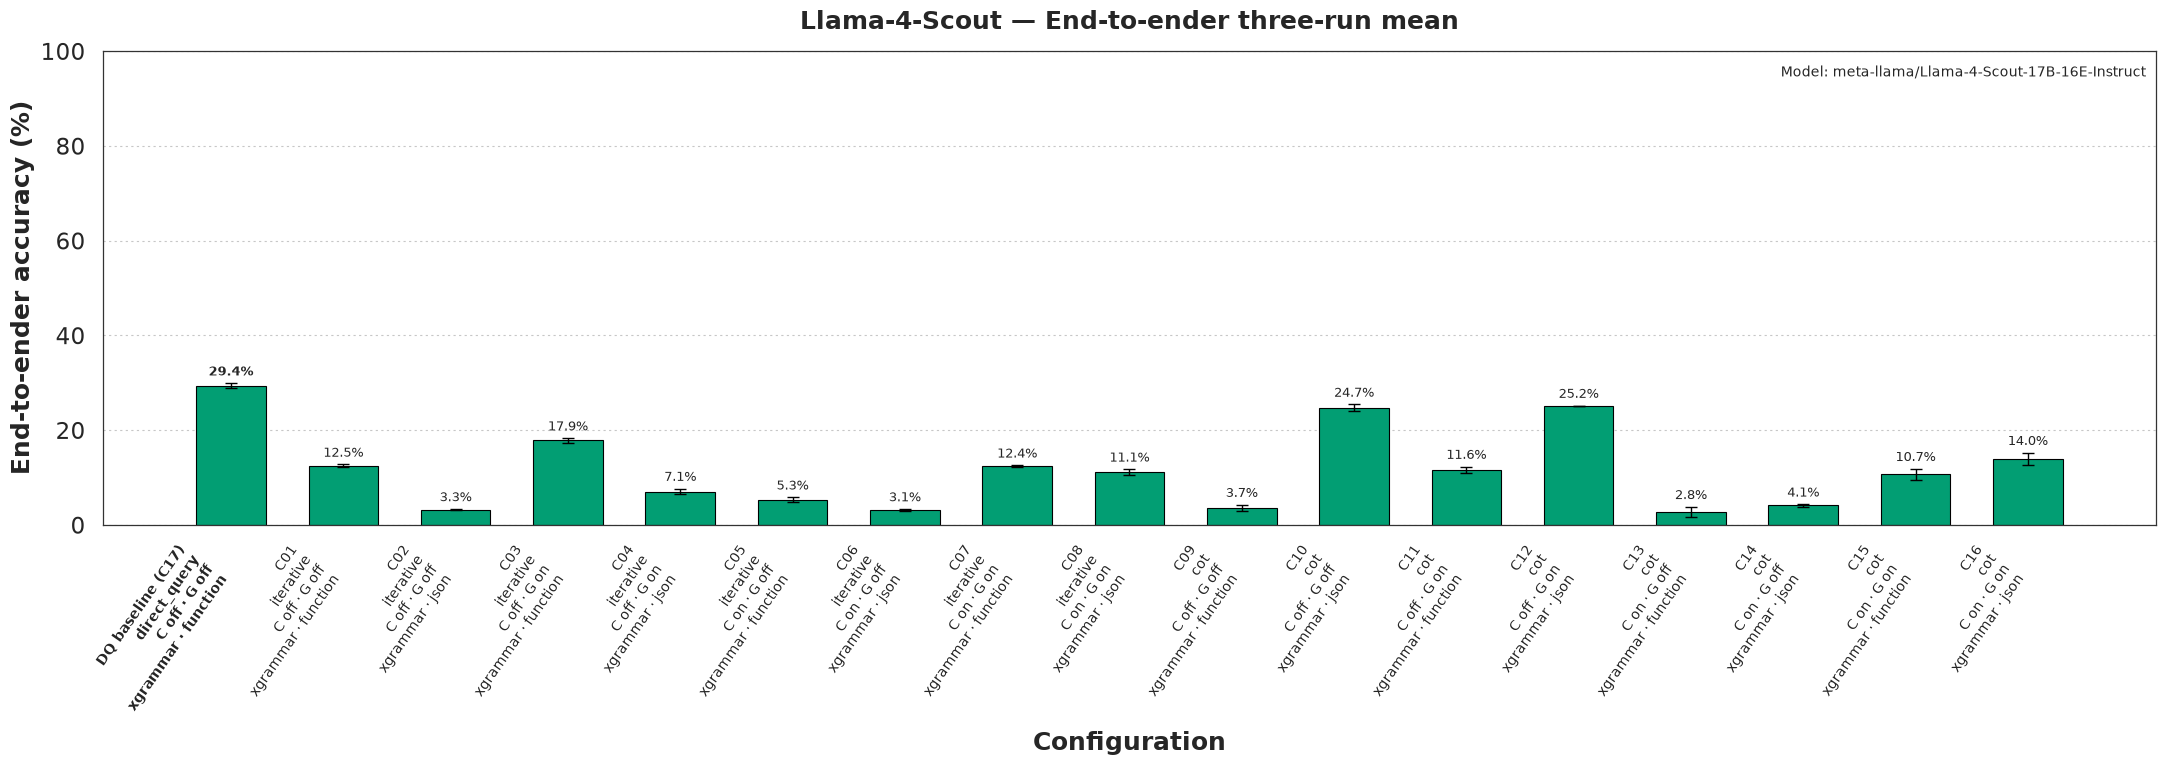

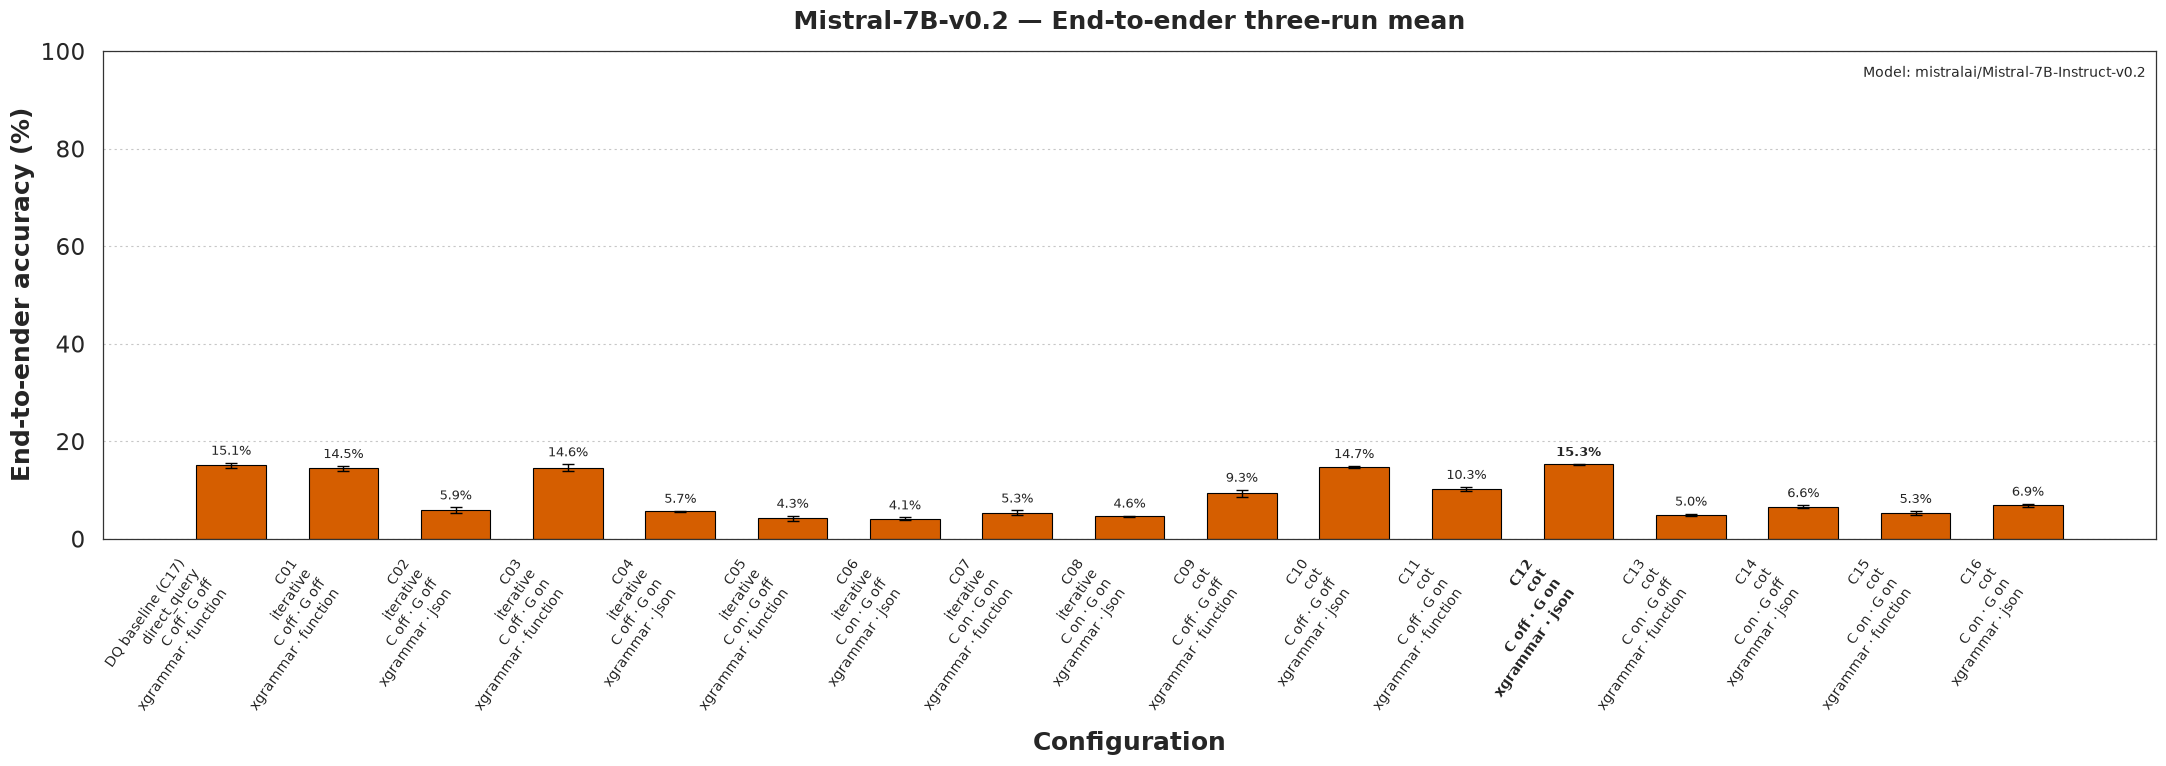

#### Per-experiment-category comparisons

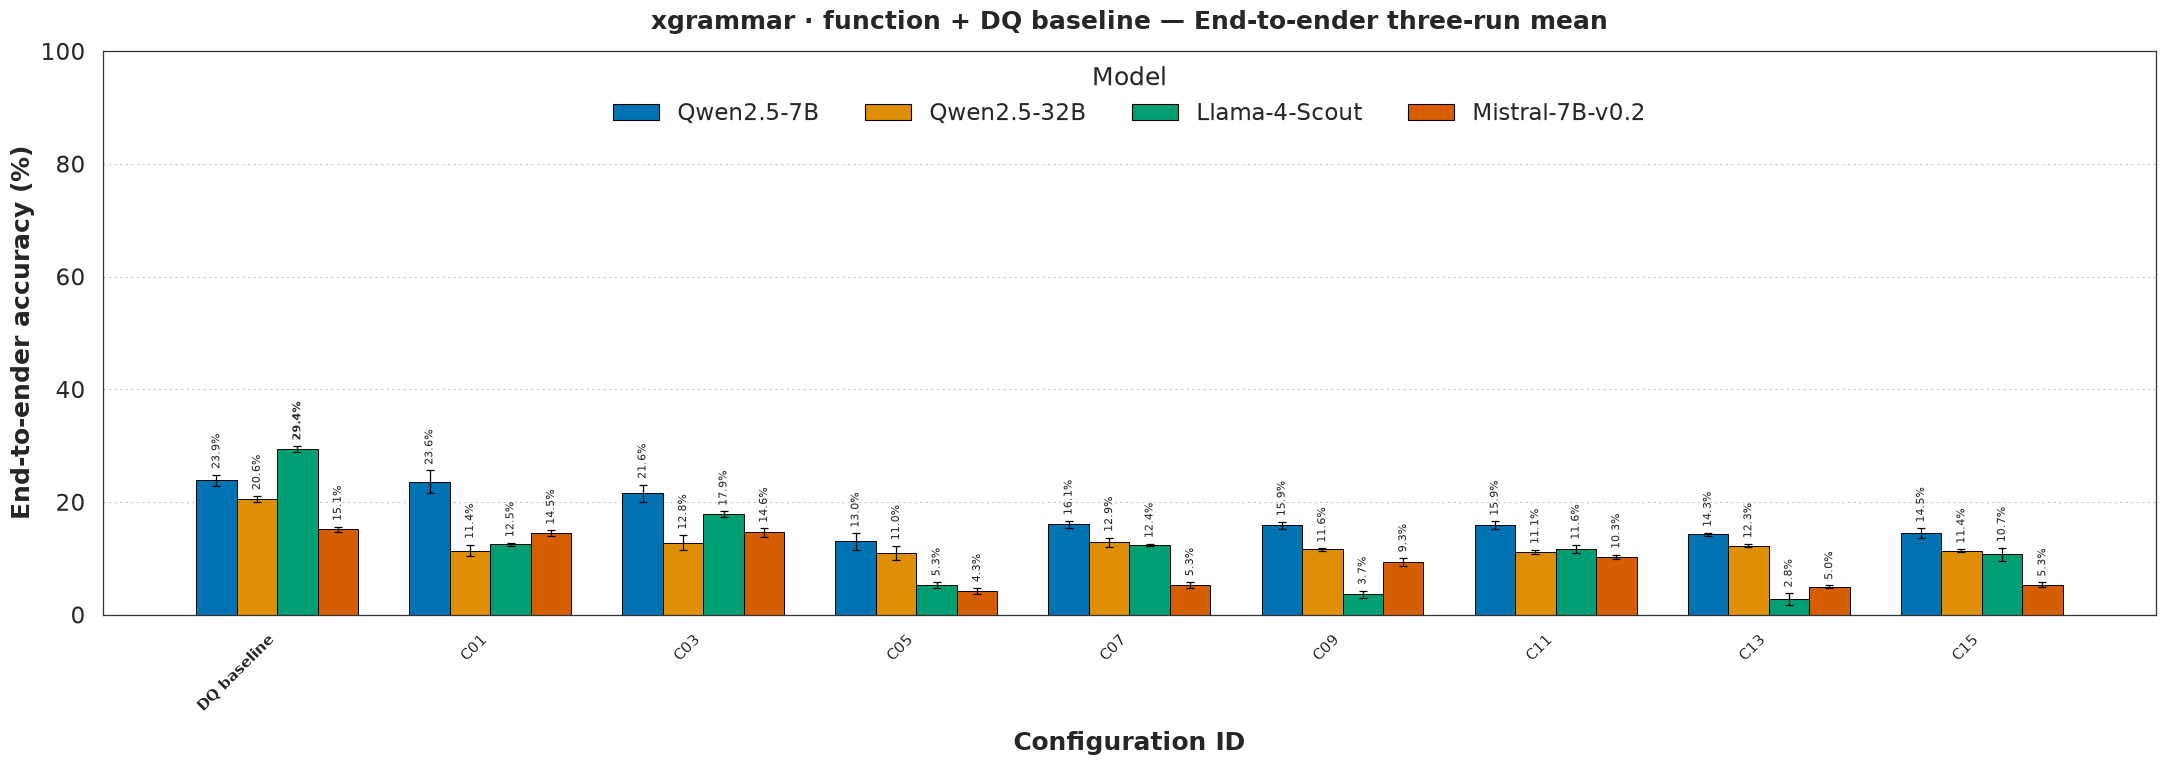

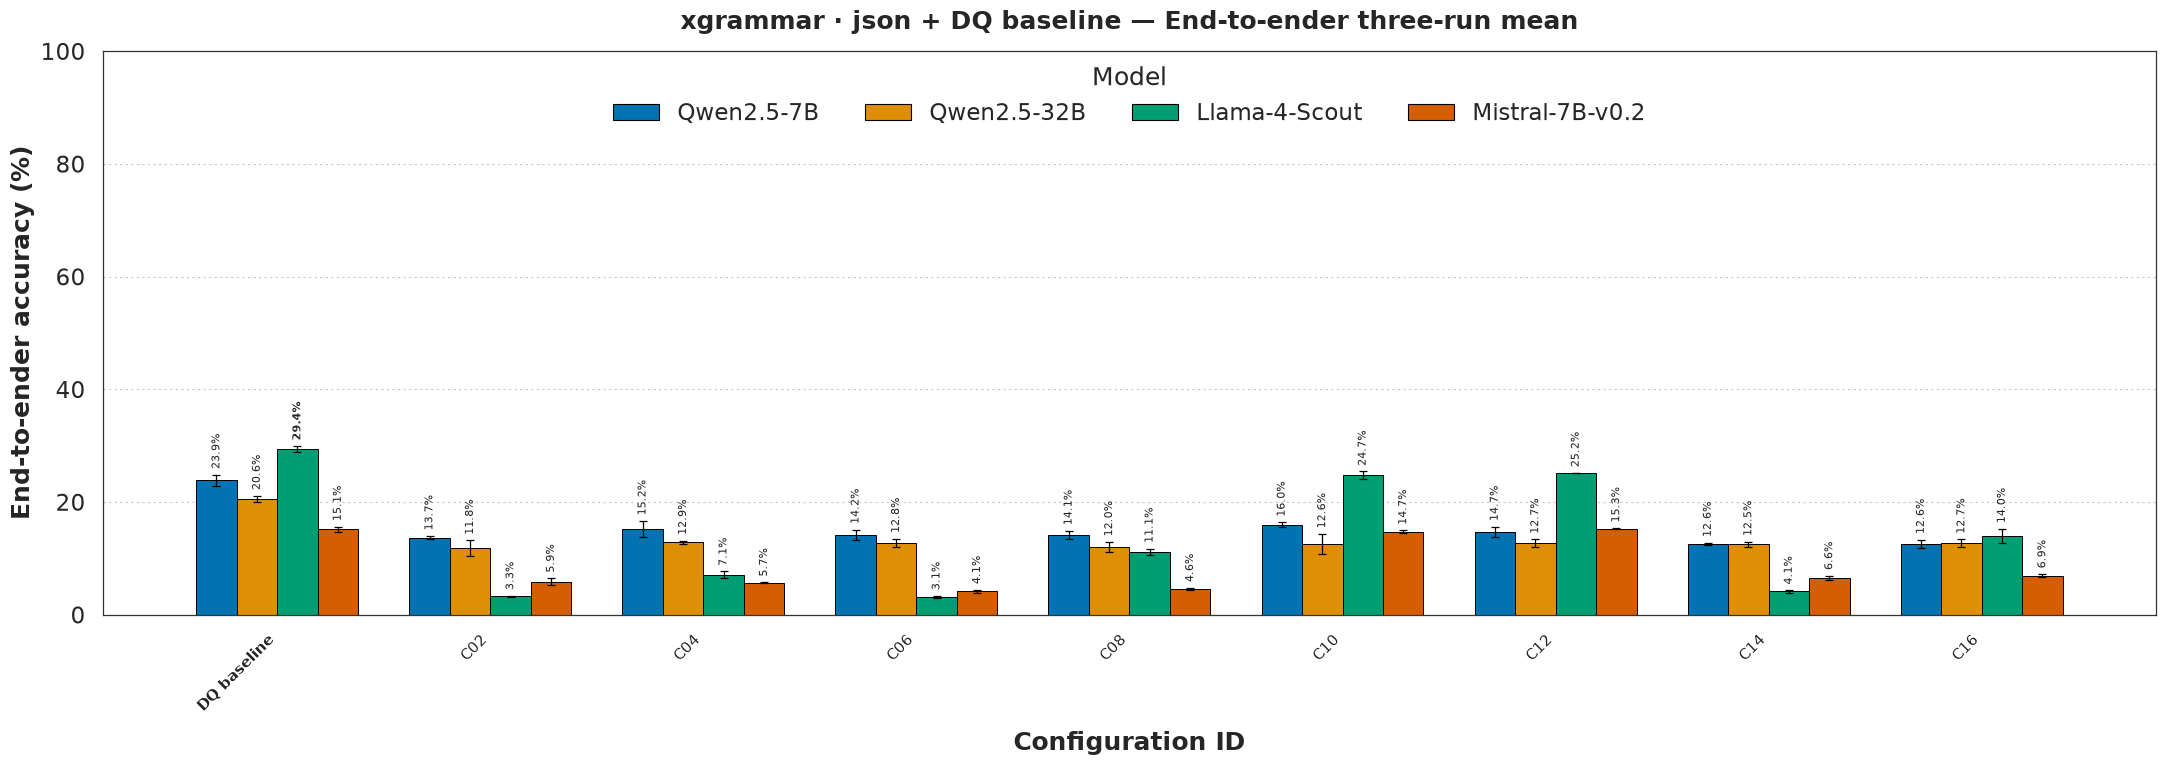

#### All configurations

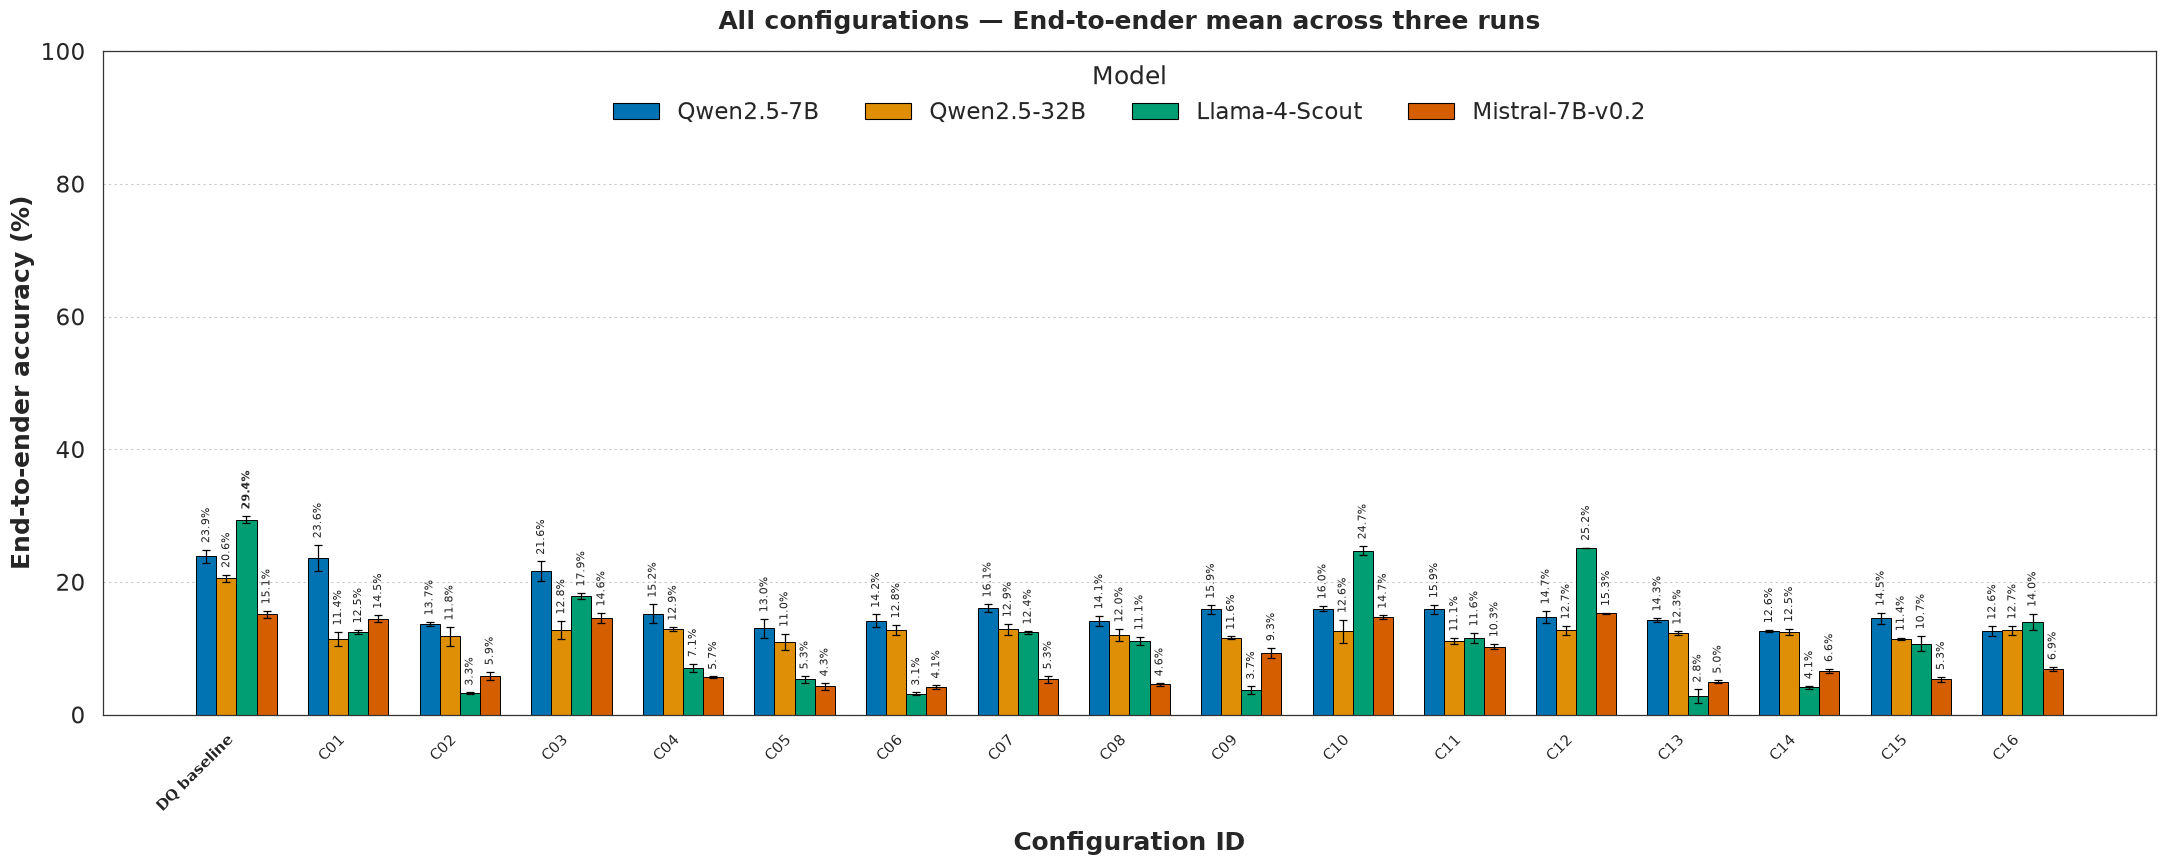

### Chain-of-thought end-to-ender

#### Per-model configurations

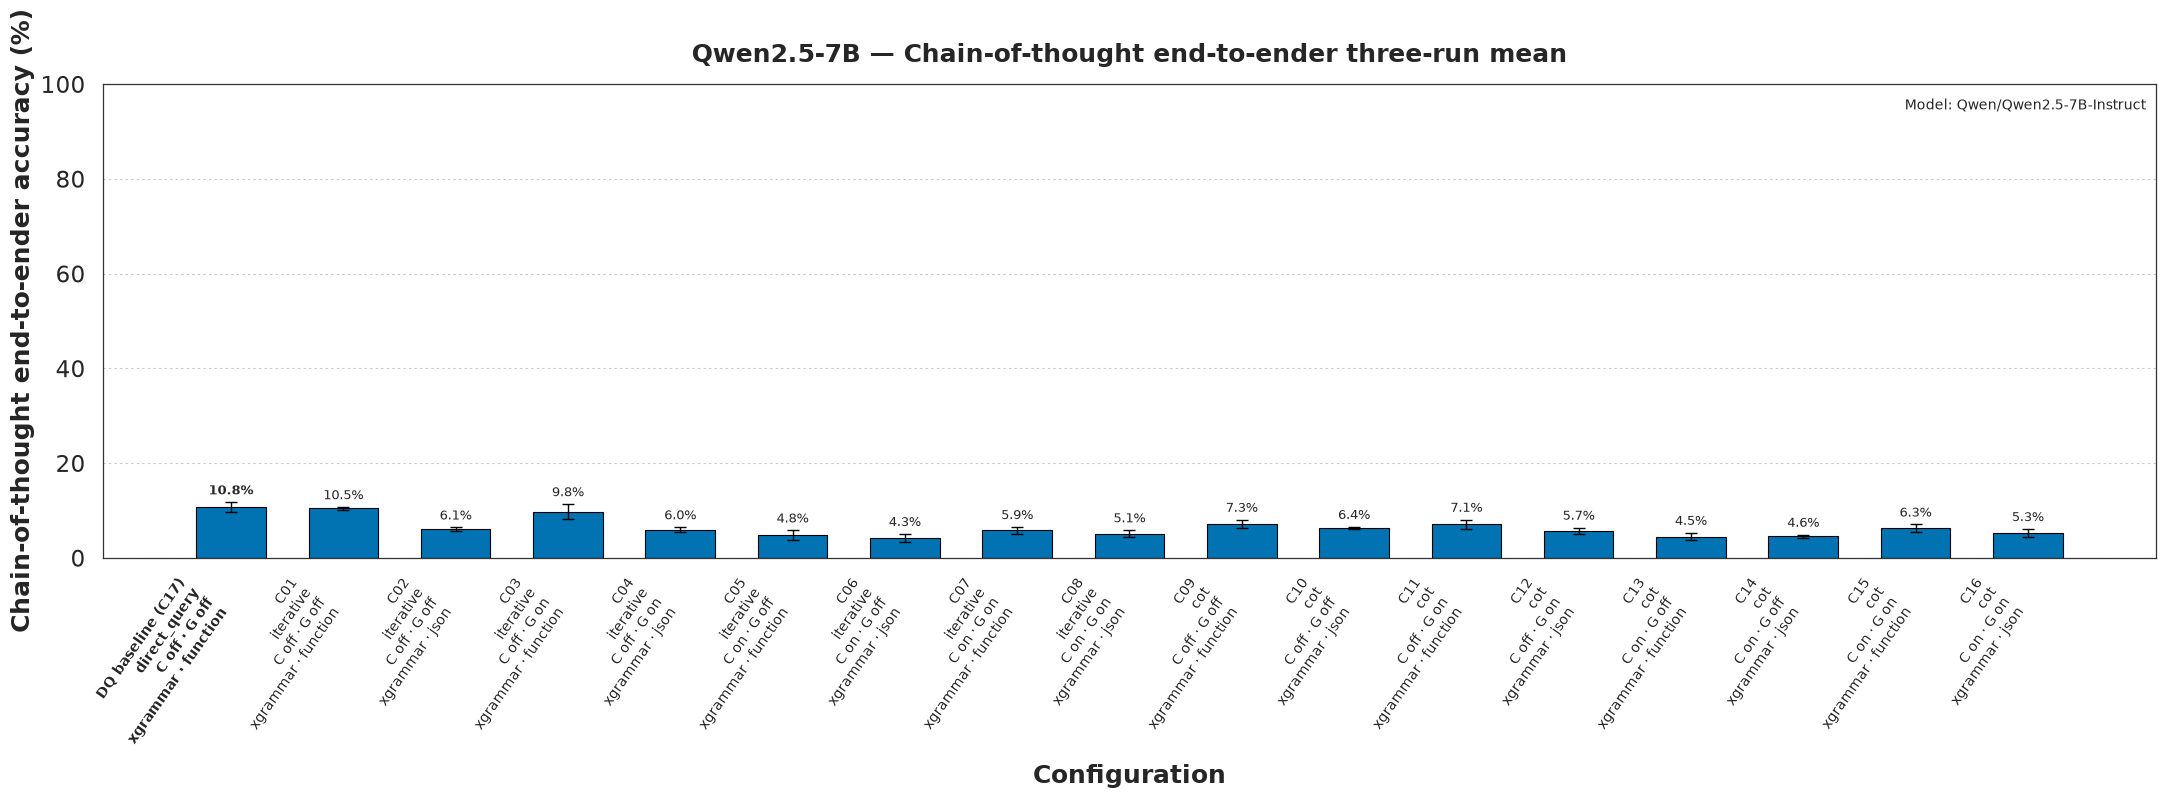

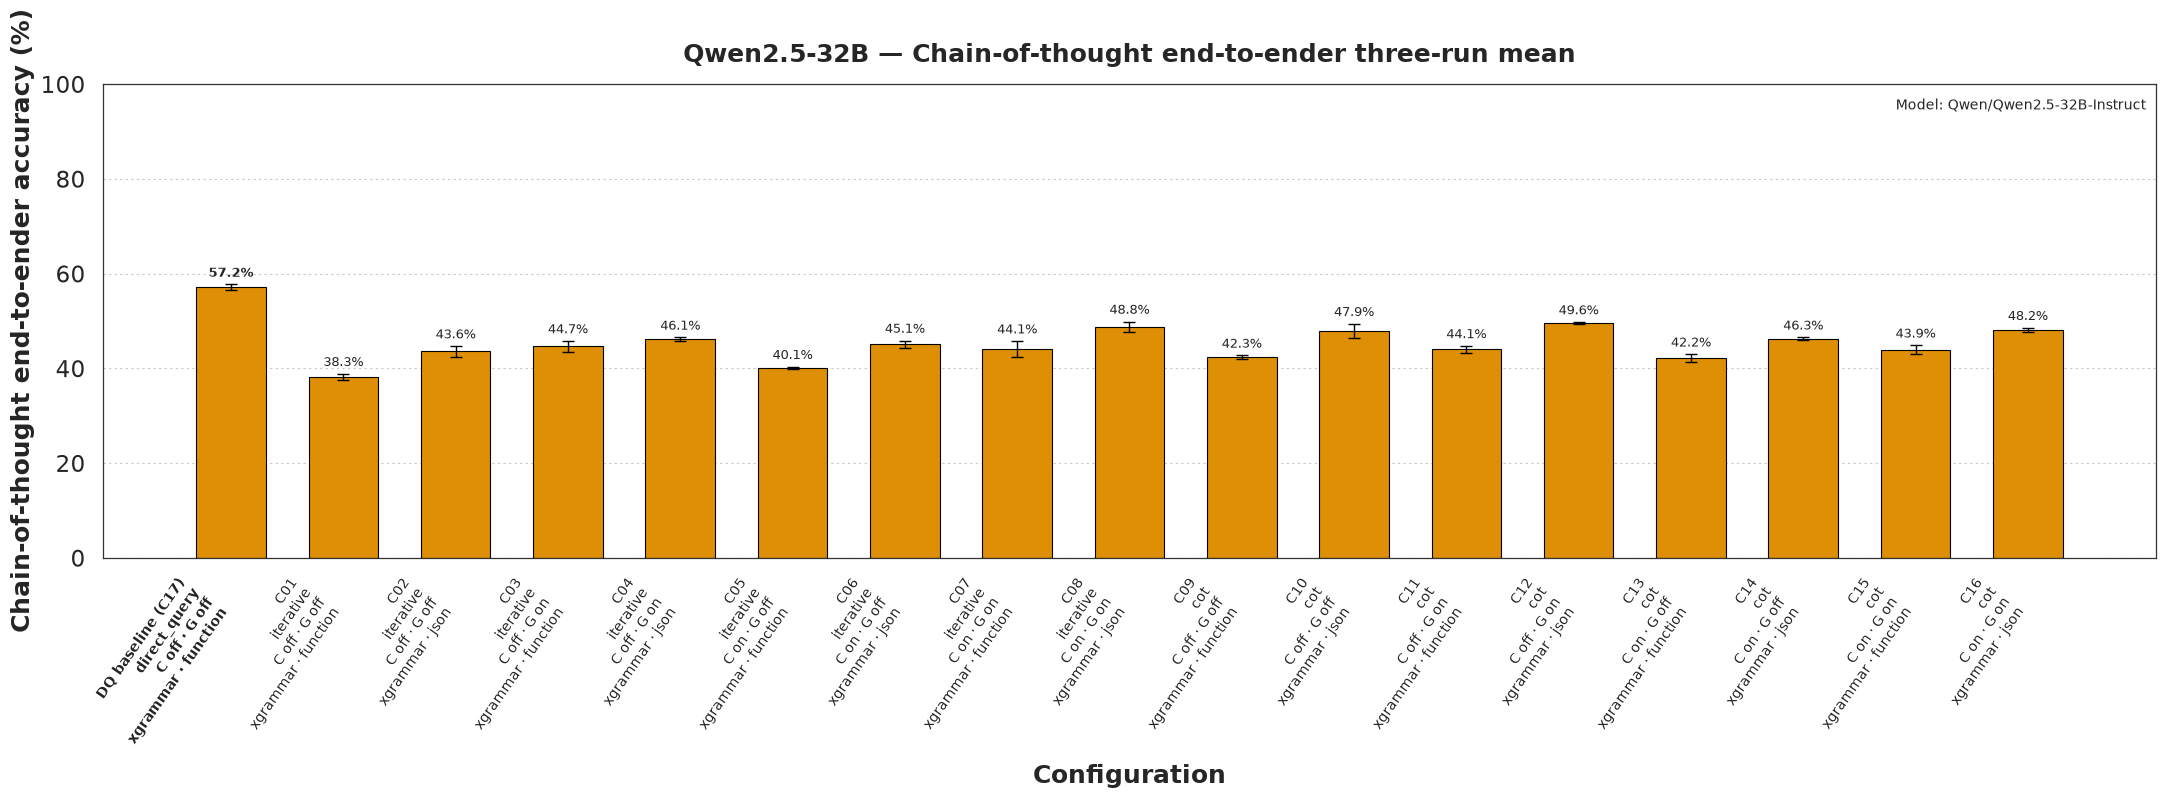

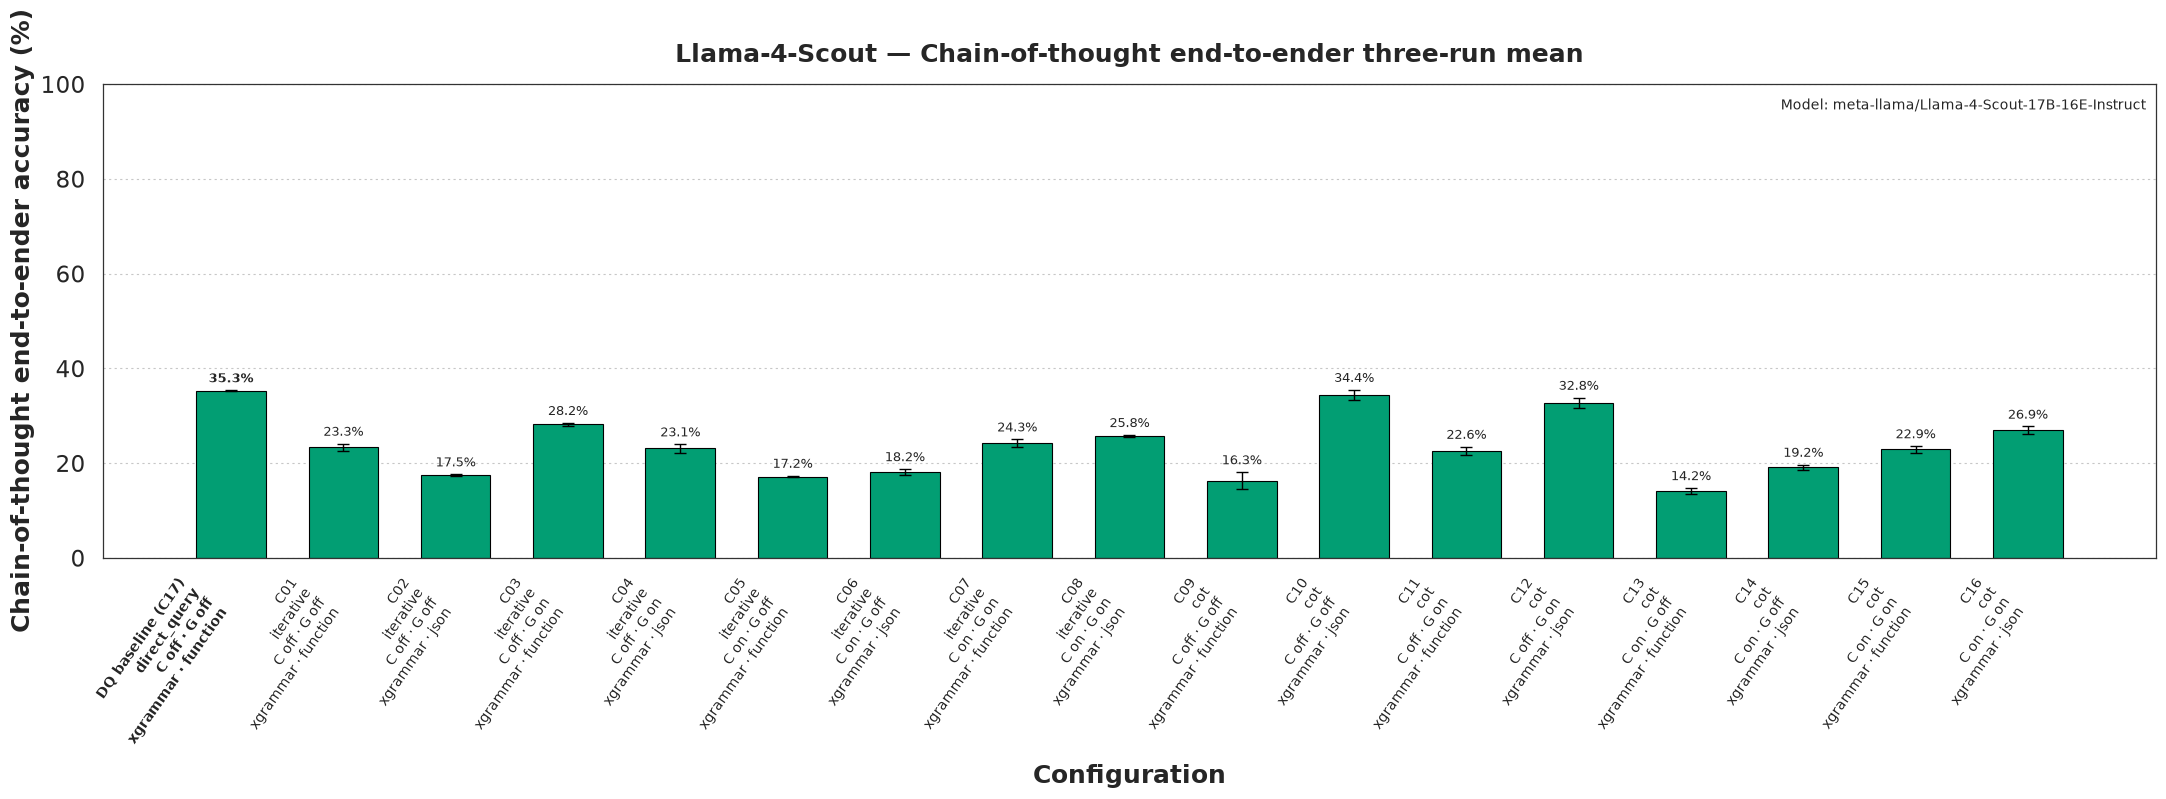

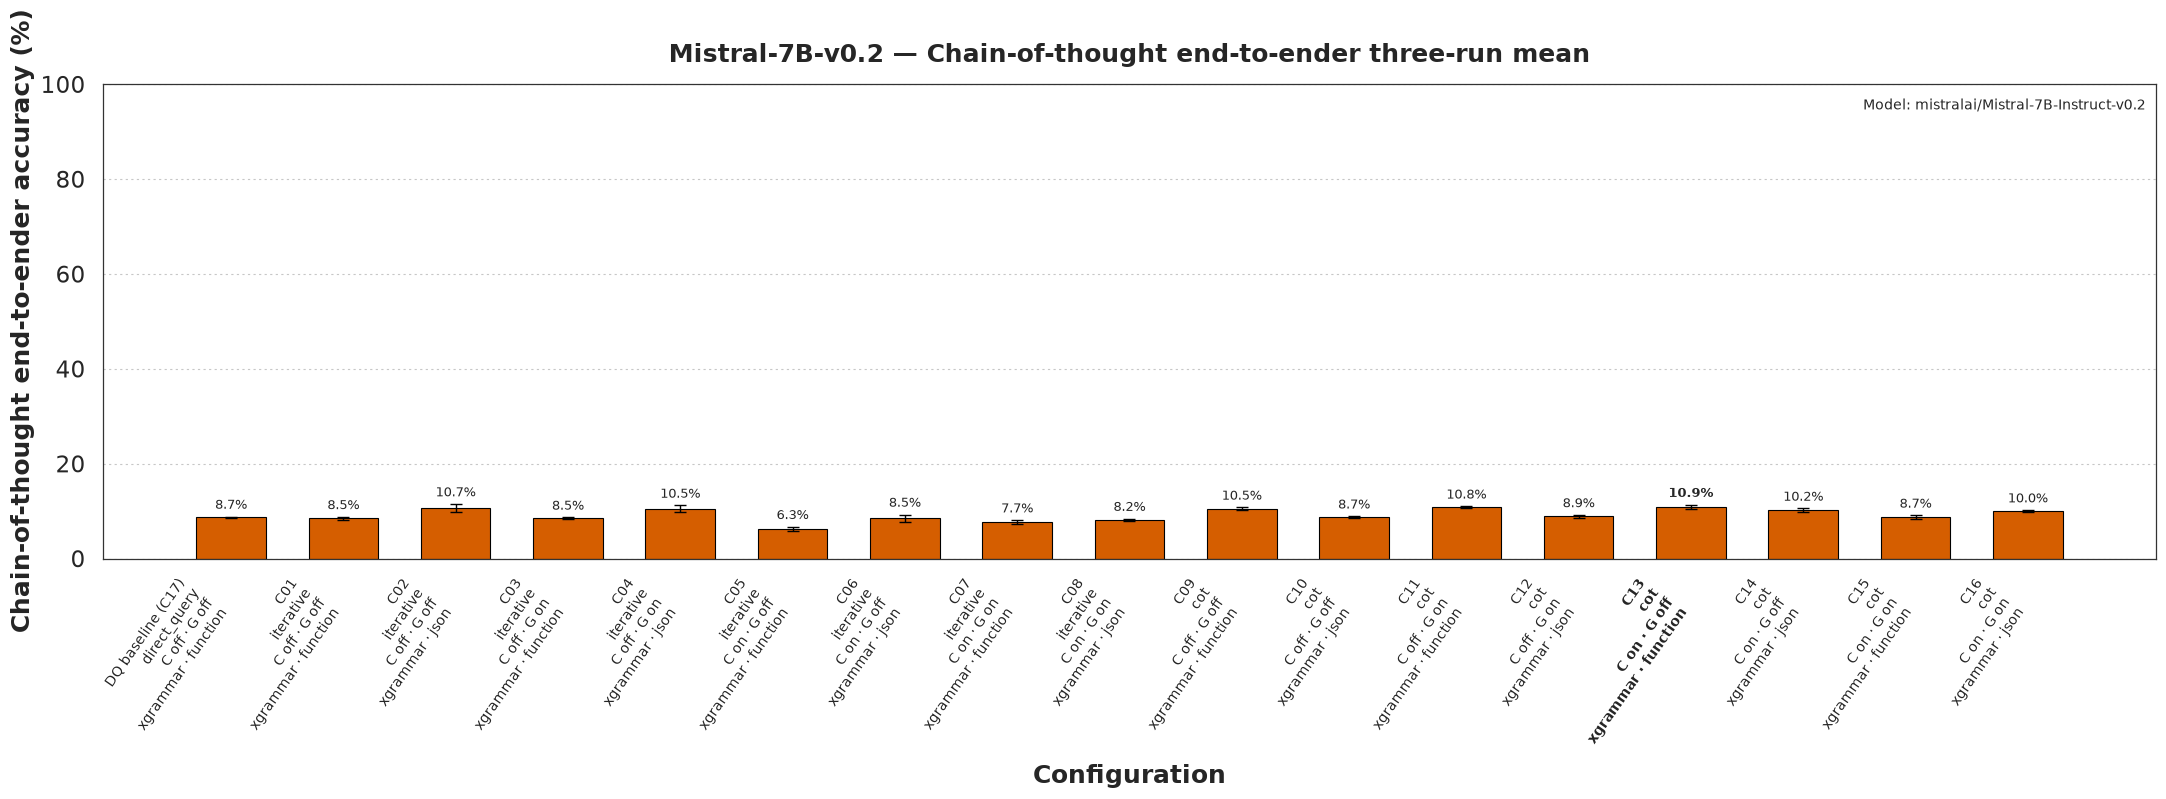

#### Per-experiment-category comparisons

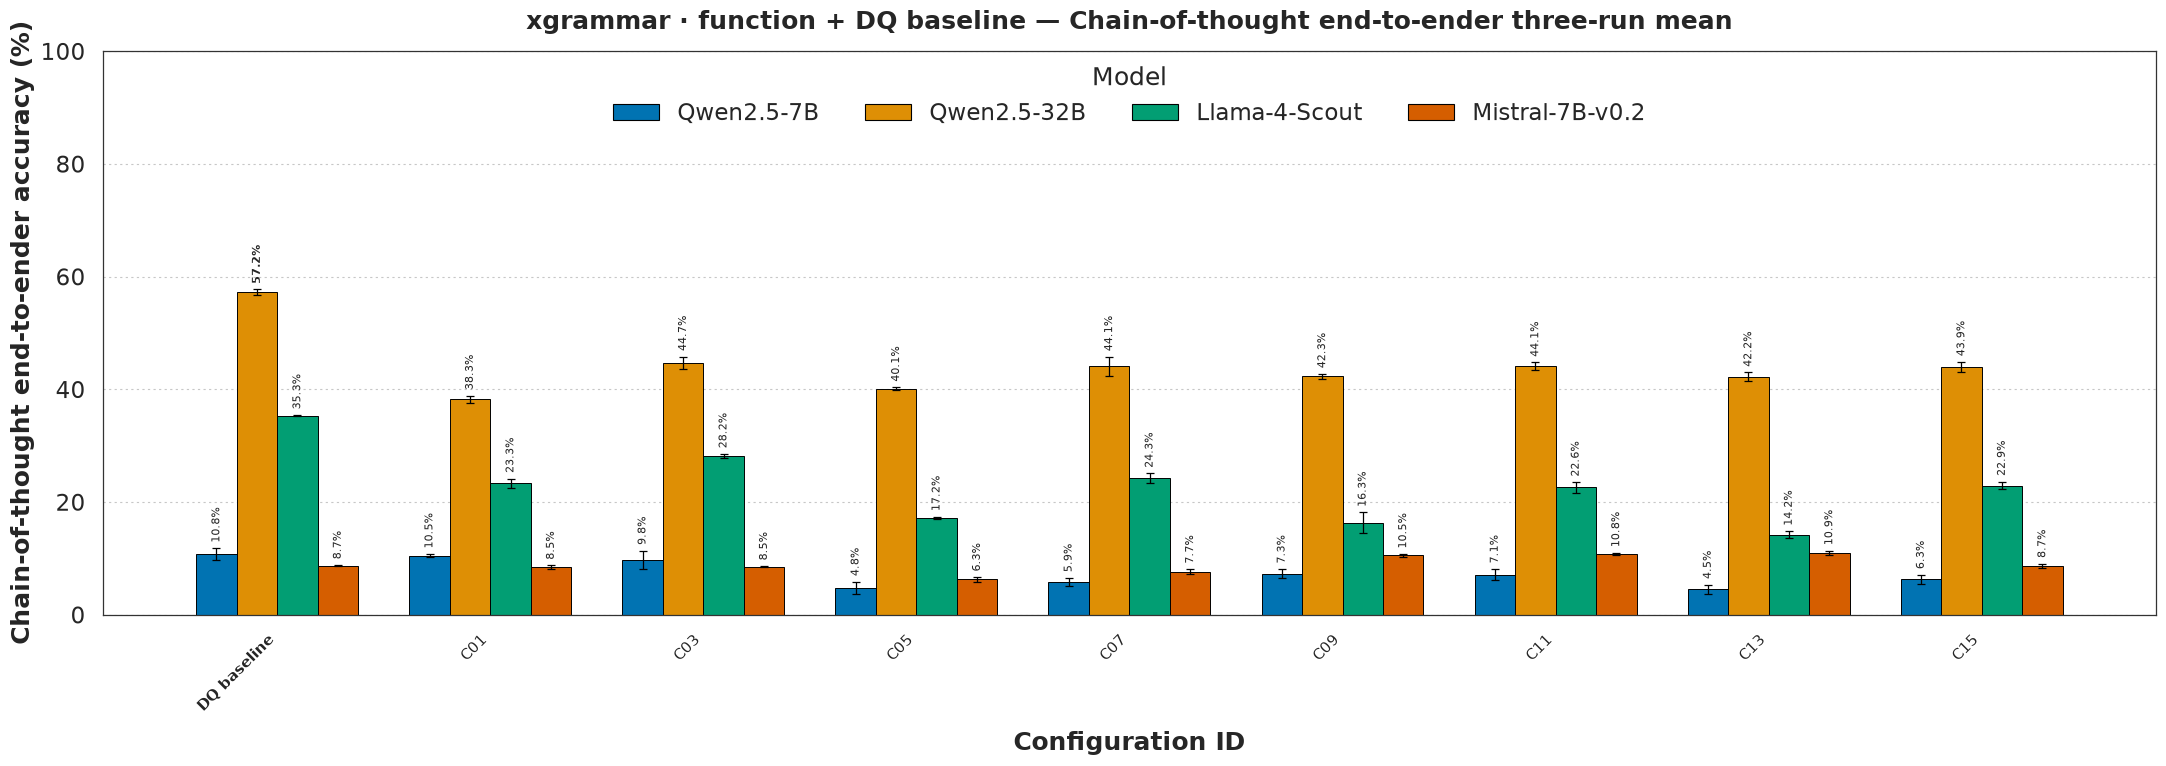

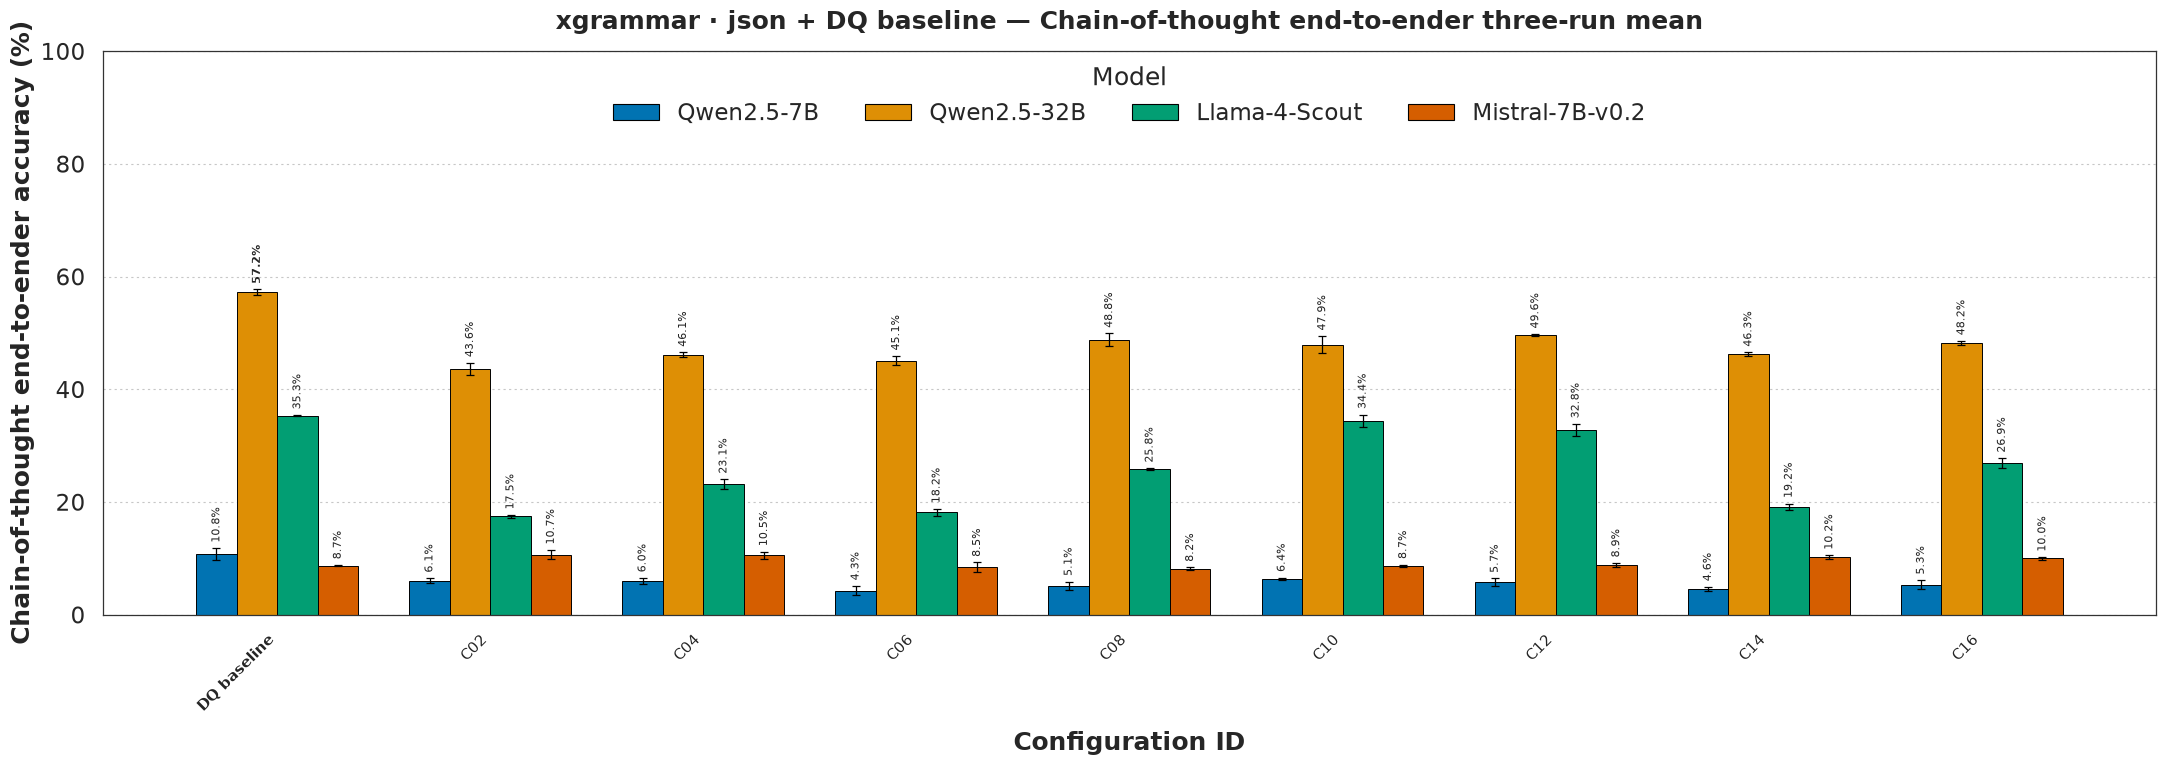

#### All configurations

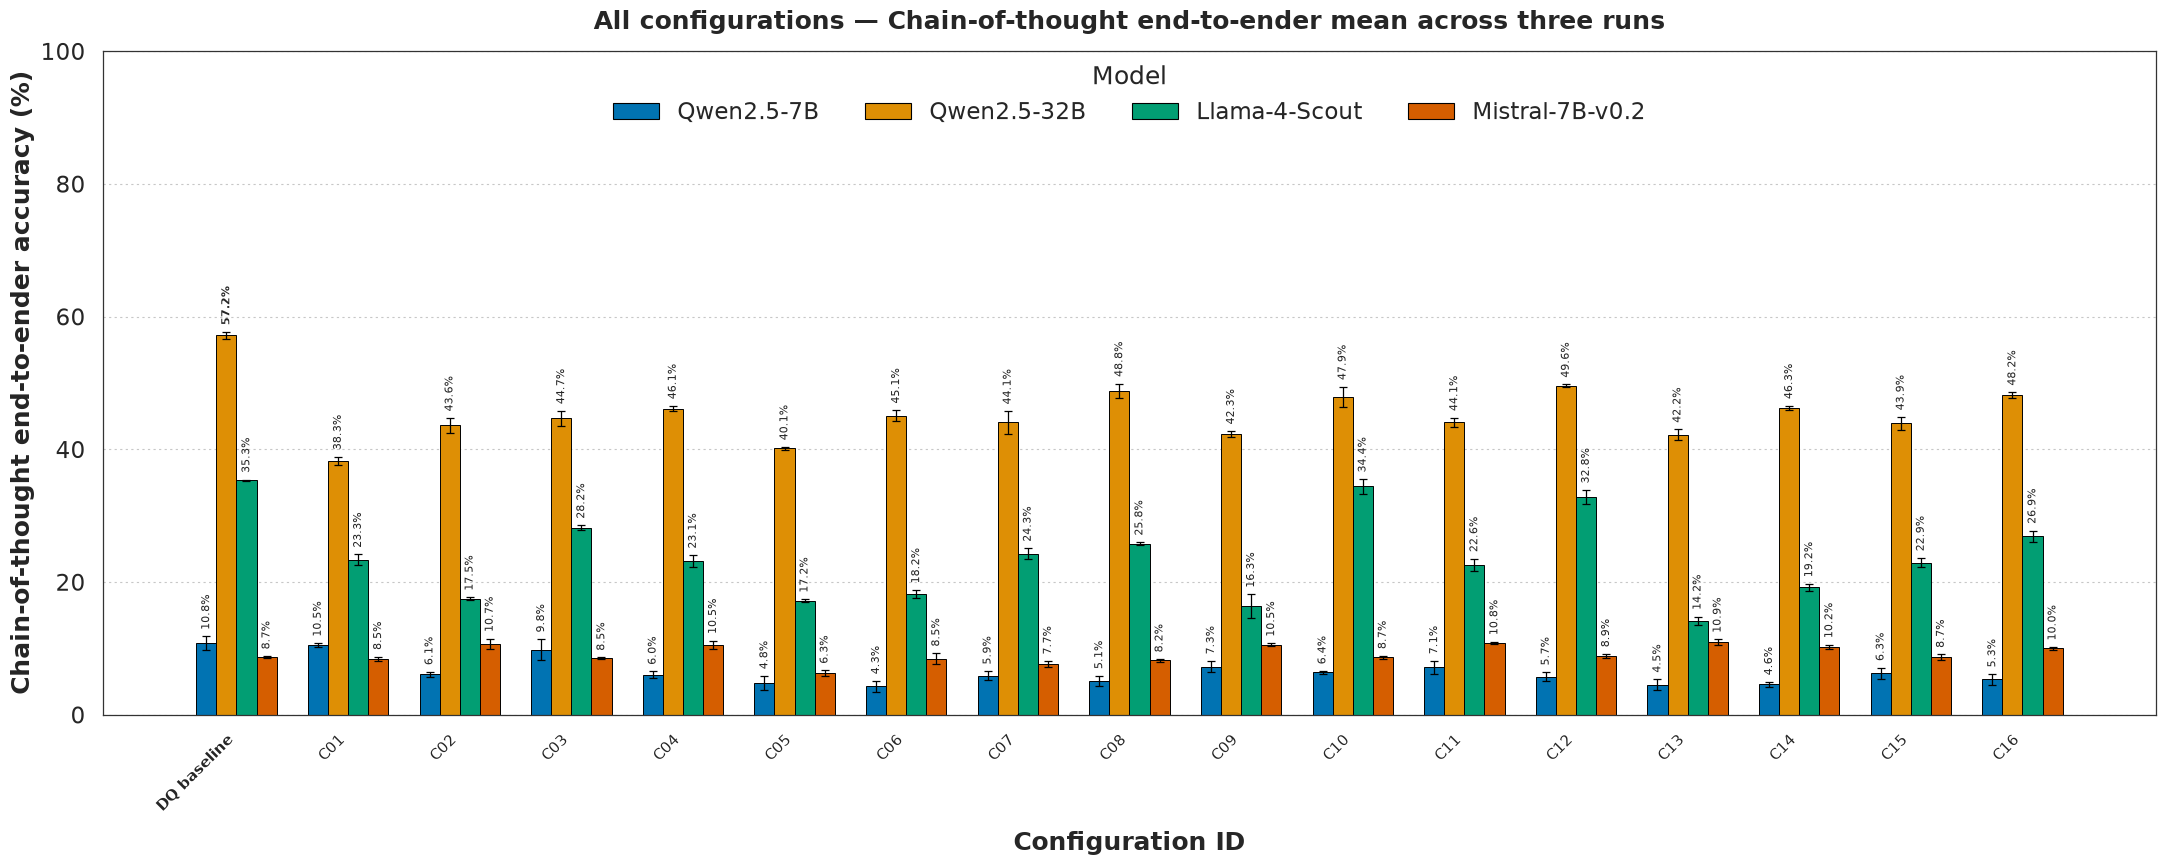

In [7]:
categories = list(dict.fromkeys(run["Category"] for run in runs))
all_configuration_ids = [DQ_BASELINE_ID] + [config_ids[config] for config in configurations if config != DQ_BASELINE_CONFIG]
full_labels = []
for config_id in all_configuration_ids:
    config = config_by_id[config_id]
    heading = f"DQ baseline ({config_id})" if config_id == DQ_BASELINE_ID else config_id
    full_labels.append(f"{heading}\n{config[0]}\nC {config[1]} · G {config[2]}\n{config[3]} · {config[4]}")

for extractor in EXTRACTORS:
    extractor_frame = summary_df[summary_df["Extractor"] == extractor]
    display(Markdown(f"### {METRIC_LABELS[extractor]}"))

    display(Markdown("#### Per-model configurations"))
    for model in models:
        model_frame = extractor_frame[extractor_frame["Model"] == model].set_index("Configuration")
        means = [model_frame.loc[config_id, "accuracy_mean"] for config_id in all_configuration_ids]
        stds = [model_frame.loc[config_id, "accuracy_std"] for config_id in all_configuration_ids]
        best_mean = max(means)
        best_configurations = {config_id for config_id, value in zip(all_configuration_ids, means) if abs(value - best_mean) < 1e-12}
        positions = pd.Series(range(len(all_configuration_ids)), dtype=float)
        fig, ax = plt.subplots(figsize=(22, 8))
        bars = ax.bar(
            positions,
            means,
            yerr=stds,
            width=0.62,
            color=MODEL_COLORS[model],
            edgecolor="black",
            linewidth=0.8,
            ecolor="black",
            capsize=4,
            error_kw={"elinewidth": 1.0, "capthick": 1.0},
        )
        for bar, config_id, value, std in zip(bars, all_configuration_ids, means, stds):
            annotate_bar(ax, bar, value, std, config_id in best_configurations)
        ax.set_xticks(positions, full_labels, rotation=55, ha="right", fontsize=10)
        emphasize_ticks(ax, best_configurations)
        style_accuracy_axis(
            ax,
            f"{MODEL_LABELS[model]} — {METRIC_LABELS[extractor]} three-run mean",
            "Configuration",
            extractor,
        )
        ax.text(0.995, 0.97, f"Model: {model}", transform=ax.transAxes, ha="right", va="top", fontsize=10)
        fig.tight_layout()
        plt.show()

    display(Markdown("#### Per-experiment-category comparisons"))
    for category in categories:
        category_config_ids = [DQ_BASELINE_ID] + [
            config_ids[config] for config in configurations if config != DQ_BASELINE_CONFIG and f"{config[3]} · {config[4]}" == category
        ]
        category_frame = extractor_frame[extractor_frame["Configuration"].isin(category_config_ids)]
        category_labels = [CONFIGURATION_PLOT_LABELS[config_id] for config_id in category_config_ids]
        positions = pd.Series(range(len(category_config_ids)), dtype=float)
        fig, ax = plt.subplots(figsize=(22, 8))
        best_configurations = grouped_model_bars(ax, category_frame, positions, category_config_ids)
        ax.set_xticks(positions, category_labels, rotation=45, ha="right", fontsize=11)
        emphasize_ticks(ax, best_configurations)
        style_accuracy_axis(
            ax,
            f"{category} + DQ baseline — {METRIC_LABELS[extractor]} three-run mean",
            "Configuration ID",
            extractor,
        )
        add_model_legend(ax)
        fig.tight_layout()
        plt.show()

    display(Markdown("#### All configurations"))
    positions = pd.Series(range(len(all_configuration_ids)), dtype=float)
    fig, ax = plt.subplots(figsize=(22, 9))
    best_configurations = grouped_model_bars(ax, extractor_frame, positions, all_configuration_ids, bar_width=0.18)
    ax.set_xticks(positions, [CONFIGURATION_PLOT_LABELS[c] for c in all_configuration_ids], rotation=45, ha="right", fontsize=11)
    emphasize_ticks(ax, best_configurations)
    style_accuracy_axis(
        ax,
        f"All configurations — {METRIC_LABELS[extractor]} mean across three runs",
        "Configuration ID",
        extractor,
    )
    add_model_legend(ax)
    fig.tight_layout()
    plt.show()

## Reading the plots

- Extractors are shown separately in this order: Direct query, NL-to-SQL, NL-to-code, End-to-ender, and Chain-of-thought end-to-ender.
- **DQ baseline** is the `direct_query` action-free baseline configuration (`C17`). It is the first bar/group and is repeated as a reference in every category plot.
- Every bar is the arithmetic mean for one extractor across exactly three 500-example runs; there is no mean across extractors.
- Black capped error bars show sample standard deviation across the three runs.
- The exact three-run mean percentage is printed above every bar.
- The highest mean configuration in each plot has a bold score and bold x-axis label; tied maxima are all bold.
- Accuracy is always shown on the same fixed 0–100% scale.
- Model colors are consistent in every figure, and thin black outlines separate adjacent bars.
- Resolve each `Cxx` label in the configuration catalog to recover strategy, constraints, global constraints, backend, and format.
- Horizontal light-gray dotted gridlines aid comparison. Vertical gridlines are disabled, and all four spines remain visible.

The completeness assertions verify that all five extractor scores were loaded for all 204 successful runs.